# Meshstatic v2 — Análisis de compresión lossless guiada por LLM

Pipeline de compresión **lossless** para radio LoRa usando un modelo de lenguaje (LM) como predictor de tokens.

## Cómo funciona

El **emisor** tokeniza el texto con el vocabulario del modelo. Para cada token, consulta al LM la distribución de probabilidad del siguiente token dado el contexto anterior. Si el token correcto aparece dentro del **top-64**, se transmite solo su **rank** (posición en el ranking) en lugar del token completo:

| Rank | Bits transmitidos | Descripción |
|---|---|---|
| 0 | **1 bit** | El LM predijo exactamente el token correcto |
| 1–3 | **4 bits** | Alta confianza, top-4 |
| 4–15 | **7 bits** | Confianza media, top-16 |
| 16–63 | **10 bits** | Confianza baja, top-64 |
| OOV | **~23 bits** | Token fuera del top-64 → vocab ID compacto (LlamaCpp) |

El **receptor** tiene el mismo modelo y el mismo contexto. Al recibir el rank `k`, recupera el `k`-ésimo token más probable → reconstrucción exacta, bit a bit.

## Cómo leer el ratio de compresión

`ratio_llm` es el **porcentaje de ahorro**: cuánto se redujo el tamaño respecto al original.

- **Positivo** → comprime: `+56%` significa que se transmitió un 56% menos de bytes.
- **Negativo** → overhead: `-666%` en un mensaje de 3 bytes (`Ok.`) significa que el paquete LLM pesa ~7x más que el texto crudo. **Para mensajes muy cortos siempre habrá overhead** — el sistema automáticamente detecta esto y cae al modo `raw` (envía los bytes directamente sin compresión).

El sistema elige automáticamente el modo más eficiente: `lossless/lossless` si la compresión gana, `lossless/raw` si el overhead supera al original.

---
**Requisito**: dos nodos corriendo:
```bash
# Nodo 1:  ./run_docker.sh up  →  http://localhost:8001
# Nodo 2:  ./run_docker.sh up  →  http://localhost:8002
```

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import gzip
import lzma
import json
import re
import time
import os

pd.set_option('display.max_colwidth', 80)
pd.set_option('display.float_format', '{:.1f}'.format)

# Compresor zstd (opcional)
try:
    import zstandard as _zstd_lib
    def zstd_size(b):
        return len(_zstd_lib.ZstdCompressor(level=22).compress(b))
    _zstd_ok = True
except ImportError:
    def zstd_size(b):
        return len(b)
    _zstd_ok = False
    print('zstandard no disponible (pip install zstandard)')

# Estadistica
from scipy import stats as sp_stats

def bootstrap_ci(arr, stat=np.mean, n_boot=2000, ci=95, seed=42):
    arr = np.asarray(arr, dtype=float)
    if len(arr) < 2:
        m = float(stat(arr)); return m, m
    rng = np.random.default_rng(seed)
    boots = rng.choice(arr, size=(n_boot, len(arr)), replace=True)
    s = np.apply_along_axis(stat, 1, boots)
    lo = (100 - ci) / 2
    return float(np.percentile(s, lo)), float(np.percentile(s, 100 - lo))

ALFA = os.getenv('NODO_ALFA_URL', 'http://localhost:8001')
BETA = os.getenv('NODO_BETA_URL', 'http://localhost:8002')
ALFA_PEER = ALFA.replace('localhost', 'host.docker.internal')
BETA_PEER = BETA.replace('localhost', 'host.docker.internal')

print(f'Nodo Alfa: {ALFA}  (peer: {ALFA_PEER})')
print(f'Nodo Beta: {BETA}  (peer: {BETA_PEER})')
print(f'zstandard: {"OK" if _zstd_ok else "no instalado"}')
print()

MODELO_NOMBRE = 'desconocido'
nodos_ok = True
for nombre, url in [('Alfa', ALFA), ('Beta', BETA)]:
    try:
        d = requests.get(f'{url}/api/estado', timeout=5).json()
        print(f'  OK {nombre}: node_id={d["node_id"]}  backend={d["backend"]}')
        MODELO_NOMBRE = d.get('backend', MODELO_NOMBRE)
    except Exception as e:
        print(f'  ERROR {nombre}: {e}')
        nodos_ok = False

if not nodos_ok:
    print('\nAlgun nodo no responde.')

Nodo Alfa: http://localhost:8001  (peer: http://host.docker.internal:8001)
Nodo Beta: http://localhost:8002  (peer: http://host.docker.internal:8002)
zstandard: OK

  OK Alfa: node_id=nodo-1  backend=llamacpp
  OK Beta: node_id=nodo-2  backend=llamacpp


## 1. Configurar canales entre nodos

In [2]:
def get_or_create_canal(nodo_url, nombre, peer_url):
    canales = requests.get(f'{nodo_url}/api/canales', timeout=5).json()
    for c in canales:
        if c.get('peer_url', '').rstrip('/') == peer_url.rstrip('/'):
            print(f'  Canal existente: {c["nombre"]} -> {c["peer_url"]} (id: {c["id"]})')
            return c
    r = requests.post(f'{nodo_url}/api/canales',
        json={'nombre': nombre, 'peer_url': peer_url}, timeout=10)
    c = r.json()
    print(f'  Canal creado: {c["nombre"]} -> {c["peer_url"]} (id: {c["id"]})')
    return c

print('Configurando canales...')
canal_ab = get_or_create_canal(ALFA, 'nodo-beta', BETA_PEER)
canal_ba = get_or_create_canal(BETA, 'nodo-alfa', ALFA_PEER)
CANAL_AB = canal_ab['id']
CANAL_BA = canal_ba['id']
print(f'\nA->B: {CANAL_AB}  |  B->A: {CANAL_BA}')


Configurando canales...
  Canal existente: nodo-beta -> http://host.docker.internal:8002 (id: FBF41F78)
  Canal existente: nodo-alfa -> http://host.docker.internal:8001 (id: B74C17E9)

A->B: FBF41F78  |  B->A: B74C17E9


## 2. Mensajes de prueba

28 mensajes en 5 rangos de tamaño y 4 categorías de contenido.

| Rango | Bytes aprox. | Descripción |
|---|---|---|
| `micro` | < 20 B | Confirmaciones, ACKs |
| `corto` | 20–70 B | Mensajes operativos simples |
| `medio` | 70–200 B | Reportes con contexto |
| `largo` | 200–500 B | Reportes detallados |
| `muy_largo` | > 500 B | Textos narrativos completos |

In [3]:
# (rango, categoria, texto)
MENSAJES = [
    # MICRO (< 20 bytes)
    ('micro', 'operativo', 'Ok.'),
    ('micro', 'operativo', 'ACK.'),
    ('micro', 'operativo', 'Listo.'),
    ('micro', 'operativo', 'En camino.'),
    ('micro', 'operativo', 'Sin novedad.'),

    # CORTO (20-70 bytes)
    ('corto', 'operativo', 'Confirmado, recibido.'),
    ('corto', 'operativo', 'Hola, me reporto en buen estado.'),
    ('corto', 'operativo', 'Vamos, procedemos con el plan.'),
    ('corto', 'operativo', 'Llegue al terreno, preparo los equipos.'),
    ('corto', 'operativo', 'Necesito refuerzos en la zona sur, urgente.'),
    ('corto', 'operativo', 'No puedo conectar con la antena, hay interferencia.'),
    ('corto', 'telemetria', 'Posicion GPS: 34.6037 S, 58.3816 O.'),
    ('corto', 'telemetria', 'Bateria al 87%, senal -74 dBm, temp 23.4 C.'),
    ('corto', 'telemetria', 'Nodo 7 offline. IP 10.0.1.7. Ultimo beat: 14:32 UTC.'),

    # MEDIO (70-200 bytes)
    ('medio', 'operativo',
     'Unidad Delta reporta: contacto visual con objetivo en zona norte, '
     'moviendose hacia el este a velocidad moderada. Solicitamos cobertura aerea.'),
    ('medio', 'telemetria',
     'Sensores zona A: temperatura 22.1 C, humedad 68%, presion 1013 hPa, '
     'viento 12 km/h NNO. Ultima actualizacion: 09:15 UTC. Estado: nominal.'),
    ('medio', 'tecnico',
     'Error en modulo RF: timeout en handshake despues de 3 intentos. '
     'Reiniciando interfaz. Si persiste, escalar a soporte nivel 2.'),
    ('medio', 'operativo',
     'Reporte de situacion: todos los puestos confirmados, rotacion de guardia '
     'completada sin novedades. Proxima verificacion programada para las 18:00 hs.'),
    ('medio', 'narrativo',
     'El sistema de comunicaciones LoRa permite enviar mensajes a grandes distancias '
     'con muy poca energia, lo que lo hace ideal para sensores remotos y situaciones '
     'de emergencia donde la infraestructura convencional no esta disponible.'),

    # LARGO (200-500 bytes)
    ('largo', 'operativo',
     'Reporte de incidente sector norte 11:47 UTC: se detecto falla en el nodo '
     'repetidor R-04 ubicado en la coordenada 34.72 S 58.42 O. El equipo de campo '
     'fue despachado y llego al sitio a las 12:15. Se identifico un corte en el '
     'cable de alimentacion por probable vandalismo. Se realizo reparacion temporal '
     'con materiales de emergencia. Nodo restaurado a las 13:05. Se solicita '
     'programar mantenimiento preventivo para la semana proxima.'),
    ('largo', 'narrativo',
     'La red de sensores desplegada en el area urbana comenzo a operar en enero. '
     'Cada nodo transmite datos de temperatura, humedad y calidad del aire cada '
     'cinco minutos usando LoRa. El gateway central procesa los datos y los envia '
     'a la nube para analisis en tiempo real. El sistema demostro una disponibilidad '
     'del 98.7% durante el primer trimestre, con solo dos interrupciones menores '
     'causadas por cortes de energia en zonas perifericas.'),
    ('largo', 'tecnico',
     'Especificacion del enlace de radio: frecuencia 915 MHz, potencia 20 dBm, '
     'ganancia de antena 3 dBi, sensibilidad del receptor -137 dBm, spreading '
     'factor SF10, ancho de banda 125 kHz, coding rate 4/5. Distancia maxima '
     'validada en campo: 8.3 km en zona rural con linea de vista parcial. '
     'RSSI promedio: -112 dBm. SNR promedio: 6.2 dB. Tiempo en el aire por '
     'paquete de 50 bytes: 330 ms a SF10.'),

    # MUY LARGO (> 500 bytes)
    ('muy_largo', 'narrativo',
     'Los protocolos de comunicacion inalambrica de largo alcance han transformado '
     'la manera en que los sistemas de monitoreo remoto recopilan y transmiten datos. '
     'A diferencia de las redes celulares convencionales, que requieren una '
     'infraestructura costosa y consumen grandes cantidades de energia, las redes '
     'LoRa operan en bandas de frecuencia libres y pueden funcionar durante anios '
     'con una sola bateria. Esto las hace ideales para aplicaciones en agricultura '
     'de precision, monitoreo de infraestructura critica, ciudades inteligentes y '
     'comunicaciones de emergencia en zonas remotas. El desafio principal sigue '
     'siendo la capacidad de transmision: con velocidades de datos de apenas '
     'cientos de bits por segundo, cada byte que se puede ahorrar representa una '
     'mejora significativa en la eficiencia del sistema completo.'),
    ('muy_largo', 'narrativo',
     'La historia de las telecomunicaciones comenzo con el telegrafo electrico '
     'en el siglo XIX, cuando Samuel Morse demostro que era posible transmitir '
     'informacion codificada a traves de cables conductores. Este avance '
     'revolucionario permitio que los mensajes viajaran a velocidades imposibles '
     'para cualquier mensajero humano. Con el tiempo, la tecnologia evoluciono '
     'hacia el telefono, la radio, la television y finalmente las redes digitales '
     'que hoy conectan a miles de millones de personas alrededor del mundo. En el '
     'contexto moderno de las redes de sensores y los dispositivos IoT, el desafio '
     'ya no es solo transmitir informacion sino hacerlo de manera eficiente, '
     'consumiendo la menor cantidad posible de energia y ancho de banda.'),
    ('muy_largo', 'tecnico',
     'El protocolo LoRaWAN define tres clases de dispositivos segun su patron de '
     'recepcion. Los dispositivos Clase A solo pueden recibir mensajes desde el '
     'servidor inmediatamente despues de una transmision, lo que los hace muy '
     'eficientes en energia. Los dispositivos Clase B abren ventanas de recepcion '
     'programadas periodicamente usando beacons del gateway. Los dispositivos '
     'Clase C mantienen el receptor abierto en todo momento, permitiendo latencia '
     'minima a costa de mayor consumo. Para aplicaciones de telemetria con bateria, '
     'Clase A es la opcion estandar ya que permite autonomias de varios anios '
     'dependiendo de la frecuencia de transmision y el spreading factor elegido.'),
]

print(f'Total: {len(MENSAJES)} mensajes\n')
print(f'{"Rango":10s} {"Cat":12s} {"Bytes":6s}  Texto')
print('-' * 80)
for rango, cat, txt in MENSAJES:
    b = len(txt.encode())
    preview = txt[:55] + ('...' if len(txt) > 55 else '')
    print(f'{rango:10s} {cat:12s} {b:5d}B  {preview}')


Total: 25 mensajes

Rango      Cat          Bytes   Texto
--------------------------------------------------------------------------------
micro      operativo        3B  Ok.
micro      operativo        4B  ACK.
micro      operativo        6B  Listo.
micro      operativo       10B  En camino.
micro      operativo       12B  Sin novedad.
corto      operativo       21B  Confirmado, recibido.
corto      operativo       32B  Hola, me reporto en buen estado.
corto      operativo       30B  Vamos, procedemos con el plan.
corto      operativo       39B  Llegue al terreno, preparo los equipos.
corto      operativo       43B  Necesito refuerzos en la zona sur, urgente.
corto      operativo       51B  No puedo conectar con la antena, hay interferencia.
corto      telemetria      35B  Posicion GPS: 34.6037 S, 58.3816 O.
corto      telemetria      43B  Bateria al 87%, senal -74 dBm, temp 23.4 C.
corto      telemetria      52B  Nodo 7 offline. IP 10.0.1.7. Ultimo beat: 14:32 UTC.
medio      operati

## 2.5 Corpus ampliado — Wikipedia ES

Para validar estadisticamente el sistema se genera un corpus de **200 mensajes**
extraidos de articulos aleatorios de Wikipedia en espanol via su API publica REST.
Esto garantiza:
- **Diversidad tematica** real (tecnologia, historia, ciencia, cultura, geografia)
- **Rangos de tamano** controlados con seed fijo (reproducible)
- **Lenguaje natural** no curado manualmente por el investigador

El corpus se guarda en `corpus_wikipedia.json` para no re-fetchear en cada ejecucion.
La celda detecta el archivo y lo reutiliza si ya existe.

| Rango | N objetivo | Bytes |
|---|---|---|
| micro | 20 | < 25 B |
| corto | 50 | 25-80 B |
| medio | 60 | 80-230 B |
| largo | 40 | 230-550 B |
| muy_largo | 30 | 550-1000 B |

In [4]:
CORPUS_FILE  = 'corpus_wikipedia.json'
CORPUS_SEED  = 42
TARGET_N     = {'micro': 20, 'corto': 50, 'medio': 60, 'largo': 40, 'muy_largo': 30}
TOTAL_TARGET = sum(TARGET_N.values())

def _clean(text):
    import re as _re
    text = _re.sub(r'\[\d+\]', '', text)
    text = _re.sub(r'\s+', ' ', text)
    return text.strip()

def _classify(title, extract):
    low = (title + ' ' + extract[:120]).lower()
    if any(w in low for w in ['red', 'protocol', 'software', 'computadora', 'internet', 'telecomunic']):
        return 'tecnico'
    if any(w in low for w in ['historia', 'guerra', 'siglo', 'revolucion', 'imperio']):
        return 'narrativo'
    if any(w in low for w in ['municipio', 'ciudad', 'provincia', 'rio', 'montana', 'pais']):
        return 'operativo'
    return 'narrativo'

def fetch_corpus(n_articles_max=400, sleep=0.35):
    import re as _re, random as _rnd
    pool = {r: [] for r in TARGET_N}
    seen = set()
    fetched = 0
    print('Fetching Wikipedia ES...', end=' ', flush=True)
    while fetched < n_articles_max and any(len(pool[r]) < TARGET_N[r] for r in TARGET_N):
        try:
            resp = requests.get(
                'https://es.wikipedia.org/api/rest_v1/page/random/summary',
                timeout=12, headers={'User-Agent': 'meshstatic-notebook/2.0'})
            if not resp.ok:
                time.sleep(1); continue
            data  = resp.json()
            title   = data.get('title', '')
            extract = _clean(data.get('extract', ''))
            if title in seen or len(extract) < 10:
                continue
            seen.add(title)
            fetched += 1
            sents = _re.split(r'(?<=[.!?:])\s+', extract)
            for s in sents:
                b = len(s.encode('utf-8'))
                if 10 <= b <= 25   and len(pool['micro'])    < TARGET_N['micro']:    pool['micro'].append(s)
                elif 25 < b <= 80  and len(pool['corto'])    < TARGET_N['corto']:    pool['corto'].append(s)
                elif 80 < b <= 230 and len(pool['medio'])    < TARGET_N['medio']:    pool['medio'].append(s)
            for i in range(0, max(0, len(sents) - 1), 2):
                chunk = ' '.join(sents[i:i+4])
                b = len(chunk.encode('utf-8'))
                if 230 < b <= 550   and len(pool['largo'])    < TARGET_N['largo']:    pool['largo'].append(chunk)
                elif 550 < b <= 1000 and len(pool['muy_largo']) < TARGET_N['muy_largo']: pool['muy_largo'].append(chunk)
            if fetched % 20 == 0:
                total = sum(len(v) for v in pool.values())
                print(f'{total}/{TOTAL_TARGET}', end=' ', flush=True)
        except Exception:
            pass
        time.sleep(sleep)
    print('done')
    _rnd.seed(CORPUS_SEED)
    result = []
    for rango, texts in pool.items():
        _rnd.shuffle(texts)
        for t in texts[:TARGET_N[rango]]:
            result.append((rango, 'narrativo', t))
    return result

if os.path.exists(CORPUS_FILE):
    MENSAJES_WIKI = [tuple(x) for x in json.load(open(CORPUS_FILE, encoding='utf-8'))]
    print(f'Corpus cargado desde {CORPUS_FILE}: {len(MENSAJES_WIKI)} mensajes')
else:
    print('Generando corpus...')
    MENSAJES_WIKI = fetch_corpus()
    json.dump(MENSAJES_WIKI, open(CORPUS_FILE, 'w', encoding='utf-8'), ensure_ascii=False)
    print(f'Guardado en {CORPUS_FILE}')

from collections import Counter
rangos_c = Counter(r for r, _, _ in MENSAJES_WIKI)
print(f'\nDistribucion ({len(MENSAJES_WIKI)} mensajes):')
for r in ['micro', 'corto', 'medio', 'largo', 'muy_largo']:
    n = rangos_c.get(r, 0)
    sizes = [len(t.encode()) for rng, _, t in MENSAJES_WIKI if rng == r]
    if sizes:
        print(f'  {r:10s}: {n:3d} msgs | {min(sizes):4d}-{max(sizes):4d} B | media {np.mean(sizes):.0f} B')
print('\nMuestra (1 por rango):')
for r in ['micro', 'corto', 'medio', 'largo', 'muy_largo']:
    ej = next((t for rng, _, t in MENSAJES_WIKI if rng == r), None)
    if ej:
        print(f'  [{r}] {ej[:80]}{"..." if len(ej)>80 else ""}')

Corpus cargado desde corpus_wikipedia.json: 192 mensajes

Distribucion (192 mensajes):
  micro     :  14 msgs |   10-  25 B | media 18 B
  corto     :  50 msgs |   27-  80 B | media 57 B
  medio     :  60 msgs |   81- 229 B | media 130 B
  largo     :  40 msgs |  233- 536 B | media 354 B
  muy_largo :  28 msgs |  563- 937 B | media 686 B

Muestra (1 por rango):
  [micro] de Telecinco.
  [corto] Se fabrica bajo licencia en la ciudad de Falun.
  [medio] Las primeras publicaciones revisadas por pares sobre el uso de computadoras en l...
  [largo] John George Bartholomew FRSE fue un cartógrafo y geógrafo británico. Como provee...
  [muy_largo] El vuelo 982 de Ozark Air Lines era un vuelo regular programado el 27 de diciemb...


## 2.6 Corpus curado por dominio

Los corpus de internet (Wikipedia) cubren bien el espanol narrativo pero **no los dominios
de aplicacion de Meshstatic** (operativo, telemetria, tecnico). Sin un corpus curado:

- No podemos separar si el LLM comprime bien texto *en general* o texto *de dominio*.
- El tribunal no puede evaluar rendimiento en condiciones reales de uso.

Generamos **50 mensajes por dominio** con templates + aleatoridad controlada (seed=42),
totalizando ~150 mensajes curados + ~200 Wikipedia = **~350 mensajes en total**.

| Dominio | Fuente | N | Ejemplo |
|---------|--------|---|---------|
| operativo | Templates LoRa/campo | 50 | `Nodo R-01 reporta estado degradado en sector norte` |
| telemetria | Templates sensores | 50 | `Sensor N07: T=32.1C Hum=67% Bat=78% RSSI=-87dBm` |
| tecnico | Templates protocolos | 50 | `LoRaWAN SF10, 125kHz, CR=4/5, -137dBm, alcance 8km` |
| narrativo | Wikipedia ES | ~200 | (articulos de Wikipedia al azar) |


In [5]:
import random as _rnd
from collections import Counter

_r = _rnd.Random(42)   # seed fijo = reproducible exactamente

def _pick(lst):  return _r.choice(lst)
def _flt(lo, hi, d=1): return round(_r.uniform(lo, hi), d)
def _int(lo, hi): return _r.randint(lo, hi)

# === Operativo ================================================================
def gen_operativo(n=70):
    NODOS   = ['R-01','R-02','R-07','A-03','B-12','Delta','Echo','Central','Foxtrot','Sierra']
    ZONAS   = ['sector norte','sector sur','perimetro A','zona critica','base de campo',
               'punto de observacion 3','cuadrante 7','antena repetidora','torre de vigilancia']
    ESTADOS = ['nominal','degradado','sin senal','en alerta','restaurado','offline','en mantenimiento']
    ACCIONES = [
        'Solicitamos apoyo tecnico.',
        'Procediendo con protocolo de contingencia.',
        'Reiniciando interfaz de red.',
        'Verificando enlace con nodo principal.',
        'Ejecutando diagnostico remoto.',
        'Escalando a nivel 2.',
        'En espera de confirmacion del centro.',
        'Notificando al centro de control.',
        'Activando redundancia de enlace.',
        'Programando reinicio en 5 minutos.',
    ]
    msgs = []
    for _ in range(n):
        nd  = _pick(NODOS);  zn = _pick(ZONAS)
        est = _pick(ESTADOS); ac = _pick(ACCIONES)
        hh  = f'{_int(0,23):02d}:{_int(0,59):02d} UTC'
        d8  = f'2025-{_int(1,7):02d}-{_int(1,28):02d}'
        tpl = _r.randint(0, 6)
        if tpl == 0:
            t = f'Nodo {nd} reporta estado {est} en {zn}. {hh}. {ac}'
        elif tpl == 1:
            t = f'Reporte {hh}: unidad {nd} - {zn} - {est}. {ac}'
        elif tpl == 2:
            t = f'{d8} {hh} - {nd} [{zn.upper()}]: {est.capitalize()}. {ac}'
        elif tpl == 3:
            t = f'Alerta {hh}: {nd} detecta anomalia en {zn}. Estado: {est}. {ac}'
        elif tpl == 4:
            t = (f'Reporte de situacion {d8}: {nd} en {zn} confirma estado {est}. '
                 f'Proxima verificacion programada. {ac}')
        elif tpl == 5:
            t = (f'Incidente {d8} a las {hh}. Nodo afectado: {nd}, ubicado en {zn}. '
                 f'Estado actual: {est}. Accion tomada: {ac}')
        else:
            t = (f'ALERTA: {nd} reporta {est.upper()} en {zn}. '
                 f'{d8} {hh}. Se requiere intervencion. {ac}')
        msgs.append(t)
    return msgs

# === Telemetria ===============================================================
def gen_telemetria(n=70):
    msgs = []
    for _ in range(n):
        nodo = f'N{_int(1,99):02d}'
        ip   = f'10.{_int(0,5)}.{_int(0,9)}.{_int(1,254)}'
        rssi = _int(-130, -60)
        snr  = _flt(-5, 15, 1)
        bat  = _int(12, 100)
        tmp  = _flt(15.0, 45.0)
        hum  = _int(30, 95)
        pres = _flt(980, 1035, 1)
        vien = _flt(0, 45, 1)
        lat  = _flt(-55.0, -22.0, 4)
        lon  = _flt(-73.0, -53.0, 4)
        hh   = f'{_int(0,23):02d}:{_int(0,59):02d}:{_int(0,59):02d} UTC'
        sf   = _pick(['SF7','SF9','SF10','SF12'])
        tpl  = _r.randint(0, 6)
        if tpl == 0:
            t = f'Sensor {nodo}: T={tmp}C Hum={hum}% P={pres}hPa Bat={bat}% RSSI={rssi}dBm SNR={snr}dB. {hh}.'
        elif tpl == 1:
            t = f'Telemetria {hh} - {nodo} ({ip}): temperatura {tmp}C, humedad {hum}%, bateria {bat}%, {sf}, RSSI {rssi}dBm.'
        elif tpl == 2:
            t = f'GPS {nodo}: {lat}S {lon}O. Bat={bat}% RSSI={rssi}dBm. {hh}.'
        elif tpl == 3:
            t = (f'Sensores {nodo} [{hh}]: T={tmp}C H={hum}% P={pres}hPa '
                 f'viento={vien}km/h bat={bat}% enlace={sf} RSSI={rssi}dBm SNR={snr}dB.')
        elif tpl == 4:
            t = f'Nodo {nodo} offline. IP {ip}. Ultimo latido: {hh}. Bat={bat}% antes de caida.'
        elif tpl == 5:
            t = (f'Alarma: {nodo} temperatura {tmp}C supera umbral 40C. '
                 f'Bateria en {bat}%. RSSI={rssi}dBm. Revisar urgente.')
        else:
            t = (f'Reporte periodico {nodo}: operativo. {hh}. '
                 f'T={tmp}C Hum={hum}% Bat={bat}% RSSI={rssi}dBm ({sf}). GPS {lat}S {lon}O.')
        msgs.append(t)
    return msgs

# === Tecnico =================================================================
def gen_tecnico(n=70):
    PROTOS  = ['LoRaWAN','MQTT','CoAP','Modbus RTU','IEEE 802.15.4','NB-IoT','LTE-M']
    PARAMS  = ['spreading factor','ancho de banda','coding rate','potencia TX',
               'sensibilidad del receptor','tiempo en el aire','ventana de recepcion']
    MODULOS = ['gateway','end device','network server','application server']
    ERRORES = ['timeout en handshake','CRC error','overflow de buffer','colision de paquetes',
               'fallo de autenticacion','paquete duplicado','ventana de recepcion expirada']
    ACCIONES = ['Reiniciar el modulo','Verificar configuracion',
                'Actualizar firmware','Reducir SF','Ajustar potencia TX']
    msgs = []
    for _ in range(n):
        proto = _pick(PROTOS); param = _pick(PARAMS); mod = _pick(MODULOS)
        err   = _pick(ERRORES); acc = _pick(ACCIONES)
        fr    = _flt(860, 930, 1); pw = _int(14, 27)
        sf    = _pick(['SF7','SF9','SF10','SF12'])
        bw    = _pick([125, 250, 500]); cr = _pick(['4/5','4/6','4/7','4/8'])
        toa   = _int(100, 3000); dist = _int(2, 20)
        tpl   = _r.randint(0, 6)
        if tpl == 0:
            t = f'Error en {mod}: {err}. Causa: {param} mal configurado. Solucion: {acc}.'
        elif tpl == 1:
            t = (f'Config {proto}: {fr}MHz SF={sf} BW={bw}kHz CR={cr} '
                 f'Ptx={pw}dBm. ToA paquete 50B: {toa}ms.')
        elif tpl == 2:
            t = (f'{param} en {proto} debe ser {sf} para maximizar alcance en zona rural. '
                 f'Alcance esperado: {dist}km con linea de vista.')
        elif tpl == 3:
            t = (f'Diagnostico {mod}: {err} detectado. Protocolo: {proto}. '
                 f'{param} fuera de rango. Accion: {acc}.')
        elif tpl == 4:
            t = (f'{proto} clase A: {mod} abre ventana RX solo tras TX. '
                 f'Autonomia con {sf} cada 10min: varios anos en bateria AA.')
        elif tpl == 5:
            t = (f'Especificacion {proto}: {fr}MHz {sf} {bw}kHz {cr} {pw}dBm. '
                 f'Sensibilidad -137dBm. Alcance rural validado: {dist}km.')
        else:
            t = (f'Procedimiento de {acc.lower()} para {mod} con {proto}: '
                 f'verificar {param}, confirmar {fr}MHz, validar CRC de paquetes de prueba.')
        msgs.append(t)
    return msgs

# === Clasificar en rangos de tamano ==========================================
def clasificar(cat, textos):
    result = []
    for t in textos:
        b = len(t.encode('utf-8'))
        if b < 30:        rango = 'micro'
        elif b < 85:      rango = 'corto'
        elif b < 230:     rango = 'medio'
        elif b < 550:     rango = 'largo'
        else:             rango = 'muy_largo'
        result.append((rango, cat, t))
    return result

print('Generando corpus curado por dominio (seed=42)...')
_raw_op  = gen_operativo(70)
_raw_tel = gen_telemetria(70)
_raw_tec = gen_tecnico(70)

DOM_CORPUS = (
    clasificar('operativo', _raw_op[:50]) +
    clasificar('telemetria', _raw_tel[:50]) +
    clasificar('tecnico',  _raw_tec[:50])
)

print(f'Corpus dominio: {len(DOM_CORPUS)} mensajes')
for cat in ['operativo', 'telemetria', 'tecnico']:
    items = [t for _, c, t in DOM_CORPUS if c == cat]
    sizes = [len(t.encode()) for t in items]
    cnt_r = Counter(r for r, c, _ in DOM_CORPUS if c == cat)
    print(f'  {cat:12s}: {len(items):3d} msgs | '
          f'{min(sizes):3d}-{max(sizes):3d}B | '
          f'rangos={dict(cnt_r)}')

# Combinar con Wikipedia (narrativo)
MENSAJES_WIKI_LOCAL = MENSAJES_WIKI if 'MENSAJES_WIKI' in dir() else []
CORPUS_COMPLETO = DOM_CORPUS + list(MENSAJES_WIKI_LOCAL)
print(f'\nCorpus total: {len(CORPUS_COMPLETO)} mensajes '
      f'({len(DOM_CORPUS)} dominio + {len(MENSAJES_WIKI_LOCAL)} Wikipedia)')


Generando corpus curado por dominio (seed=42)...
Corpus dominio: 150 mensajes
  operativo   :  50 msgs |  79-173B | rangos={'medio': 48, 'corto': 2}
  telemetria  :  50 msgs |  63-118B | rangos={'medio': 38, 'corto': 12}
  tecnico     :  50 msgs |  81-157B | rangos={'medio': 48, 'corto': 2}

Corpus total: 342 mensajes (150 dominio + 192 Wikipedia)


## 2.7 Corpus post-corte — aislar memorización de compresión genuina

**Hipotesis**: si el LLM memorizo texto durante entrenamiento, deberia comprimir peor
texto que nunca vio. Para probarlo, buscamos articulos de Wikipedia ES **creados despues
del corte de entrenamiento de Qwen2.5** (~septiembre 2024).

- Si `ratio_postcut aprox ratio_precut` -> compresion **genuina** (patrones linguisticos generales).
- Si `ratio_postcut << ratio_precut` -> memorization bias confirmado.

La celda usa la MediaWiki `recentchanges` API para obtener titulos de articulos nuevos,
luego extrae su resumen. Cachea en `corpus_postcutoff.json`.

In [6]:
POSTCUTOFF_FILE = 'corpus_postcutoff.json'
MODEL_CUTOFF    = '2024-09-01'   # corte aproximado de Qwen2.5

def fetch_postcutoff(n_target=60, cutoff=MODEL_CUTOFF, sleep_s=0.4):
    api         = 'https://es.wikipedia.org/w/api.php'
    summary_url = 'https://es.wikipedia.org/api/rest_v1/page/summary/'
    UA          = {'User-Agent': 'meshstatic-research/2.0 (analisis academico)'}
    results, seen = [], set()
    cont_token = {}

    print(f'Buscando articulos Wikipedia ES creados despues de {cutoff}...', flush=True)
    while len(results) < n_target:
        params = {
            'action': 'query', 'list': 'recentchanges',
            'rctype': 'new', 'rcstart': f'{cutoff}T00:00:00Z',
            'rcdir': 'newer', 'rclimit': '100',
            'rcnamespace': '0', 'rcprop': 'title|timestamp',
            'format': 'json',
        }
        params.update(cont_token)
        try:
            r = requests.get(api, params=params, timeout=15, headers=UA)
            if not r.ok: break
            data = r.json()
            for item in data.get('query', {}).get('recentchanges', []):
                title = item.get('title', '')
                if not title or title in seen or ':' in title:
                    continue
                seen.add(title)
                try:
                    sr = requests.get(
                        summary_url + requests.utils.quote(title),
                        timeout=10, headers=UA)
                    if not sr.ok: continue
                    extract = re.sub(r'\s+', ' ', sr.json().get('extract', '')).strip()
                    if len(extract) < 40: continue
                    sents = re.split(r'(?<=[.!?])\s+', extract)
                    for s in sents:
                        b = len(s.encode())
                        if 80 <= b < 230 and len(results) < n_target:
                            results.append(('medio', 'narrativo_postcut', s))
                    for i in range(0, max(0, len(sents)-2), 2):
                        chunk = ' '.join(sents[i:i+3])
                        b = len(chunk.encode())
                        if 230 <= b < 550 and len(results) < n_target:
                            results.append(('largo', 'narrativo_postcut', chunk))
                    time.sleep(sleep_s)
                except Exception:
                    continue
            if 'continue' in data:
                cont_token = data['continue']
            else:
                break
        except Exception as ex:
            print(f'  API error: {ex}')
            break
    print(f'  -> {len(results)} fragmentos post-corte obtenidos')
    return results

if os.path.exists(POSTCUTOFF_FILE):
    CORPUS_POSTCUT = [tuple(x) for x in
                      json.load(open(POSTCUTOFF_FILE, encoding='utf-8'))]
    print(f'Post-cutoff cargado: {len(CORPUS_POSTCUT)} fragmentos ({POSTCUTOFF_FILE})')
else:
    CORPUS_POSTCUT = fetch_postcutoff(n_target=60)
    json.dump(CORPUS_POSTCUT, open(POSTCUTOFF_FILE, 'w', encoding='utf-8'),
              ensure_ascii=False)
    print(f'Guardado en {POSTCUTOFF_FILE}')

cnt_pc = Counter(r for r,_,_ in CORPUS_POSTCUT)
print(f'Post-corte (>{MODEL_CUTOFF}): {len(CORPUS_POSTCUT)} fragmentos | rangos={dict(cnt_pc)}')


Post-cutoff cargado: 26 fragmentos (corpus_postcutoff.json)
Post-corte (>2024-09-01): 26 fragmentos | rangos={'medio': 22, 'largo': 4}


## 2.8 Diccionario zstd entrenado en el dominio

zstd permite entrenar un diccionario de hasta 64KB sobre muestras del dominio.
Con el diccionario, zstd conoce el vocabulario antes de comprimir: esto es
**compresion clasica bien calibrada**.

Si LLM supera a zstd+dict, la ventaja no se explica solo por patrones lexicos repetibles.
Si zstd+dict aprox LLM, la ventaja del LLM es cuestionable ante un compresor clasico informado.

In [7]:
ZSTD_DICT_OBJ = None

if _zstd_ok and 'DOM_CORPUS' in dir() and DOM_CORPUS:
    train_txts    = [t for _, _, t in DOM_CORPUS if len(t) > 15]
    train_samples = [t.encode('utf-8') for t in train_txts]
    try:
        # train_dictionary() returns a ZstdCompressionDict directly — no extra wrapping needed
        ZSTD_DICT_OBJ = _zstd_lib.train_dictionary(32 * 1024, train_samples)
        dict_kb       = len(ZSTD_DICT_OBJ.as_bytes()) // 1024
        print(f'Diccionario zstd entrenado: {dict_kb} KB sobre {len(train_samples)} muestras de dominio')

        # Benchmark: mejora sobre holdout de Wikipedia (texto no visto por el diccionario)
        holdout_txts = ([t for _,_,t in MENSAJES_WIKI_LOCAL[:30]]
                        if 'MENSAJES_WIKI_LOCAL' in dir() and MENSAJES_WIKI_LOCAL
                        else train_txts[-20:])
        if holdout_txts:
            cctx_gen  = _zstd_lib.ZstdCompressor(level=22)
            cctx_dict = _zstd_lib.ZstdCompressor(level=22, dict_data=ZSTD_DICT_OBJ)
            sz_gen    = [len(cctx_gen.compress(t.encode()))  for t in holdout_txts]
            sz_dict   = [len(cctx_dict.compress(t.encode())) for t in holdout_txts]
            mejora    = np.mean([(g-d)/g*100 for g,d in zip(sz_gen, sz_dict) if g > 0])
            print(f'Mejora diccionario vs zstd generico (holdout n={len(holdout_txts)}): {mejora:+.1f}%')
    except Exception as e:
        print(f'Error entrenando diccionario zstd: {e}')
else:
    if not _zstd_ok:
        print('zstandard no instalado — pip install zstandard')
    else:
        print('Ejecuta primero cell-domain para generar DOM_CORPUS')

def zstd_dict_size(texto):
    if ZSTD_DICT_OBJ is None or not _zstd_ok:
        return zstd_size(texto.encode('utf-8'))
    cctx = _zstd_lib.ZstdCompressor(level=22, dict_data=ZSTD_DICT_OBJ)
    return len(cctx.compress(texto.encode('utf-8')))

print('zstd_dict_size() listo. Diccionario de dominio:', ZSTD_DICT_OBJ is not None)


Diccionario zstd entrenado: 12 KB sobre 150 muestras de dominio
Mejora diccionario vs zstd generico (holdout n=30): -7.2%
zstd_dict_size() listo. Diccionario de dominio: True


## 3. Enviar todos los mensajes y medir

Cada mensaje se envía de Alfa → Beta. El API espera el ACK del receptor antes de responder (sincrónico), no se necesitan delays artificiales.

In [8]:
def gzip_size(texto):
    return len(gzip.compress(texto.encode('utf-8'), compresslevel=9))

def lzma_size(texto):
    return len(lzma.compress(texto.encode('utf-8'), preset=9))

def _zstd_sz(texto):
    return zstd_size(texto.encode('utf-8')) if _zstd_ok else len(texto.encode('utf-8'))

def enviar_y_medir(canal_id, texto, rango, categoria):
    b_orig   = len(texto.encode('utf-8'))
    b_gzip   = gzip_size(texto)
    b_lzma   = lzma_size(texto)
    b_zstd   = _zstd_sz(texto)
    b_zstd_d = zstd_dict_size(texto) if 'zstd_dict_size' in dir() else b_zstd
    t0 = time.time()
    try:
        r = requests.post(
            f'{ALFA}/api/enviar',
            json={'texto': texto, 'canal_id': canal_id, 'contexto': ''},
            timeout=600,
        )
        latencia_ms = (time.time() - t0) * 1000
        if not r.ok:
            return {'error': r.text, 'texto_original': texto, 'rango': rango,
                    'categoria': categoria, 'bytes_orig': b_orig,
                    'bytes_gzip': b_gzip, 'bytes_lzma': b_lzma,
                    'bytes_zstd': b_zstd, 'bytes_zstd_dict': b_zstd_d,
                    'latencia_ms': latencia_ms, 'rangos_seq': []}
        d = r.json()
    except Exception as e:
        return {'error': str(e), 'texto_original': texto, 'rango': rango,
                'categoria': categoria, 'bytes_orig': b_orig,
                'bytes_gzip': b_gzip, 'bytes_lzma': b_lzma,
                'bytes_zstd': b_zstd, 'bytes_zstd_dict': b_zstd_d,
                'latencia_ms': (time.time() - t0) * 1000, 'rangos_seq': []}

    tx_rec  = d.get('texto_reconstruido') or ''
    n_tok   = d.get('n_tokens', 0)
    enc_ms  = d.get('encode_ms', 0.0)
    dec_ms  = d.get('decode_ms', 0.0)

    def ratio(bx): return round((1 - bx / b_orig) * 100, 1) if b_orig else 0.0

    return {
        'texto_original':     texto,
        'texto_reconstruido': tx_rec,
        'rango':              rango,
        'categoria':          categoria,
        'bytes_orig':         d.get('bytes_original', b_orig),
        'bytes_tx':           d.get('bytes_tx', b_orig),
        'bytes_gzip':         b_gzip,
        'bytes_lzma':         b_lzma,
        'bytes_zstd':         b_zstd,
        'bytes_zstd_dict':    b_zstd_d,
        'n_tokens':           n_tok,
        'ratio_llm':          d.get('ratio_pct', 0.0),
        'ratio_gzip':         ratio(b_gzip),
        'ratio_lzma':         ratio(b_lzma),
        'ratio_zstd':         ratio(b_zstd),
        'ratio_zstd_dict':    ratio(b_zstd_d),
        'encoding':           d.get('encoding', ''),
        'estado':             d.get('estado', ''),
        'latencia_ms':        latencia_ms,
        'encode_ms':          enc_ms,
        'decode_ms':          dec_ms,
        'encode_ms_por_tok':  round(enc_ms / n_tok, 1) if n_tok else 0.0,
        'decode_ms_por_tok':  round(dec_ms / n_tok, 1) if n_tok else 0.0,
        'lossless_ok':        (tx_rec == texto),
        'rank_dist':          d.get('rank_dist'),
        'rangos_seq':         d.get('rangos_seq', []),
        'error':              None,
    }

# === Decidir fuente de mensajes ===============================================
_fuentes = []
if 'CORPUS_COMPLETO' in dir() and CORPUS_COMPLETO:
    _fuentes += CORPUS_COMPLETO
    print(f'Corpus dominio + Wikipedia: {len(CORPUS_COMPLETO)} msgs')
else:
    _fuentes += MENSAJES   # fallback al corpus manual
    print(f'Corpus manual: {len(MENSAJES)} msgs')

if 'CORPUS_POSTCUT' in dir() and CORPUS_POSTCUT:
    _fuentes += CORPUS_POSTCUT
    print(f'Post-cutoff: {len(CORPUS_POSTCUT)} msgs')

FUENTE = _fuentes
print(f'\nTotal a enviar: {len(FUENTE)} mensajes')
print(f'{"#":4s} {"Rango":10s} {"Cat":13s} {"Bytes":6s} '
      f'{"LLM%":7s} {"gzip%":6s} {"LZMA%":6s} {"zstd%":6s} {"zstd+d%":8s} {"OK":4s}')
print('-'*110)

resultados = []
for i, (rango, cat, msg) in enumerate(FUENTE, 1):
    res = enviar_y_medir(CANAL_AB, msg, rango, cat)
    resultados.append(res)
    if res.get('error'):
        print(f'{i:4d} {rango:10s} {cat:13s}  ERROR: {str(res["error"])[:35]}')
    else:
        ok = 'OK' if res['lossless_ok'] else 'FAIL'
        print(f'{i:4d} {rango:10s} {cat:13s} '
              f'{res["bytes_orig"]:5d}B '
              f'{res["ratio_llm"]:+6.1f}% '
              f'{res["ratio_gzip"]:+5.1f}% '
              f'{res["ratio_lzma"]:+5.1f}% '
              f'{res["ratio_zstd"]:+5.1f}% '
              f'{res["ratio_zstd_dict"]:+7.1f}% '
              f' {ok:4s}')

df = pd.DataFrame(resultados)
df_ok = df[df['error'].isna()].copy()
n_postcut = (df_ok['categoria'] == 'narrativo_postcut').sum()
n_domain  = df_ok['categoria'].isin(['operativo','telemetria','tecnico']).sum()
print(f'\nCompletado: {len(df)} total | errores: {df["error"].notna().sum()} | '
      f'lossless OK: {int(df_ok["lossless_ok"].sum())}/{len(df_ok)} | '
      f'dominio: {n_domain} | post-corte: {n_postcut}')


Corpus dominio + Wikipedia: 342 msgs
Post-cutoff: 26 msgs

Total a enviar: 368 mensajes
#    Rango      Cat           Bytes  LLM%    gzip%  LZMA%  zstd%  zstd+d%  OK  
--------------------------------------------------------------------------------------------------------------


   1 medio      operativo        91B  +33.0% -13.2% -62.6%  +4.4%    +4.4%  OK  
   2 medio      operativo        98B  +43.9%  -7.1% -59.2% +10.2%   +10.2%  OK  
   3 medio      operativo       118B  +34.7%  +0.8% -45.8% +14.4%   +14.4%  OK  
   4 medio      operativo       161B  +46.0%  +8.1% -26.7% +16.1%   +16.1%  OK  
   5 medio      operativo       101B  +41.6%  -9.9% -54.5%  +7.9%    +7.9%  OK  
   6 medio      operativo       143B  +43.4%  +4.9% -37.1% +14.0%   +14.0%  OK  
   7 medio      operativo       170B  +53.5% +10.6% -24.7% +19.4%   +19.4%  OK  
   8 medio      operativo       110B  +35.5%  -2.7% -52.7% +12.7%   +12.7%  OK  
   9 medio      operativo       168B  +50.6%  +9.5% -26.2% +18.5%   +18.5%  OK  
  10 medio      operativo       145B  +40.7%  +5.5% -35.2% +13.8%   +13.8%  OK  
  11 medio      operativo       163B  +53.4%  +9.2% -27.6% +17.2%   +17.2%  OK  
  12 medio      operativo       117B  +35.0%  -8.5% -53.8%  +6.0%    +6.0%  OK  
  13 medio      operativo   

## 4. Verificación lossless

In [9]:
n_ok  = int(df_ok['lossless_ok'].sum())
n_tot = len(df_ok)
n_err = int(df['error'].notna().sum())

print('=' * 55)
print('  VERIFICACION LOSSLESS')
print('=' * 55)
print(f'  Mensajes enviados         : {len(df)}')
print(f'  Errores de transmision    : {n_err}')
print(f'  Recibidos correctamente   : {n_tot}')
print(f'  Lossless perfectos (100%) : {n_ok}/{n_tot}')
print('=' * 55)

fallos = df_ok[~df_ok['lossless_ok']]
if not fallos.empty:
    print('\nMensajes con reconstruccion incorrecta:')
    for _, row in fallos.iterrows():
        print(f'  Original : {row["texto_original"][:80]}')
        print(f'  Recibido : {row["texto_reconstruido"][:80]}')
        print()
else:
    print('\nTodos los mensajes reconstruidos correctamente.')


  VERIFICACION LOSSLESS
  Mensajes enviados         : 368
  Errores de transmision    : 0
  Recibidos correctamente   : 368
  Lossless perfectos (100%) : 366/368

Mensajes con reconstruccion incorrecta:
  Original : El significado de Anubis, Inpu en egipcio antiguo, Anub en corto, Ἄνουβις (Anubi
  Recibido : El significado de Anubis, Inpu en egipcio antiguo, Anub en corto, ���νουβις (Anu

  Original : Anubis es el guardián de las tumbas asociado con la muerte y la vida después de 
  Recibido : Anubis es el guardián de las tumbas asociado con la muerte y la vida después de 



## 5. Análisis de compresión

### ¿Cuándo conviene usar el LM?

El LM tiene un overhead fijo de cabecera (~7 bytes: header + CRC32 + N_tokens). Para mensajes cortos, ese overhead supera el ahorro de compresión → el sistema cae a modo `raw` automáticamente.

**Punto de quiebre (breakeven)**: el tamaño a partir del cual la compresión LLM empieza a ganar terreno. Por debajo de ese punto, `modo=raw` es la decisión correcta.

### ¿Cómo se compara con gzip?

gzip tampoco funciona bien en textos cortos (su cabecera tiene ~18 bytes de overhead), pero su ventaja sobre LLM en textos más largos es que no necesita tiempo de inferencia.

**La ventaja real del LM**: para textos en lenguaje natural largo (>70 bytes), supera a gzip porque explota la estructura semántica del texto, no solo la repetición de bytes.

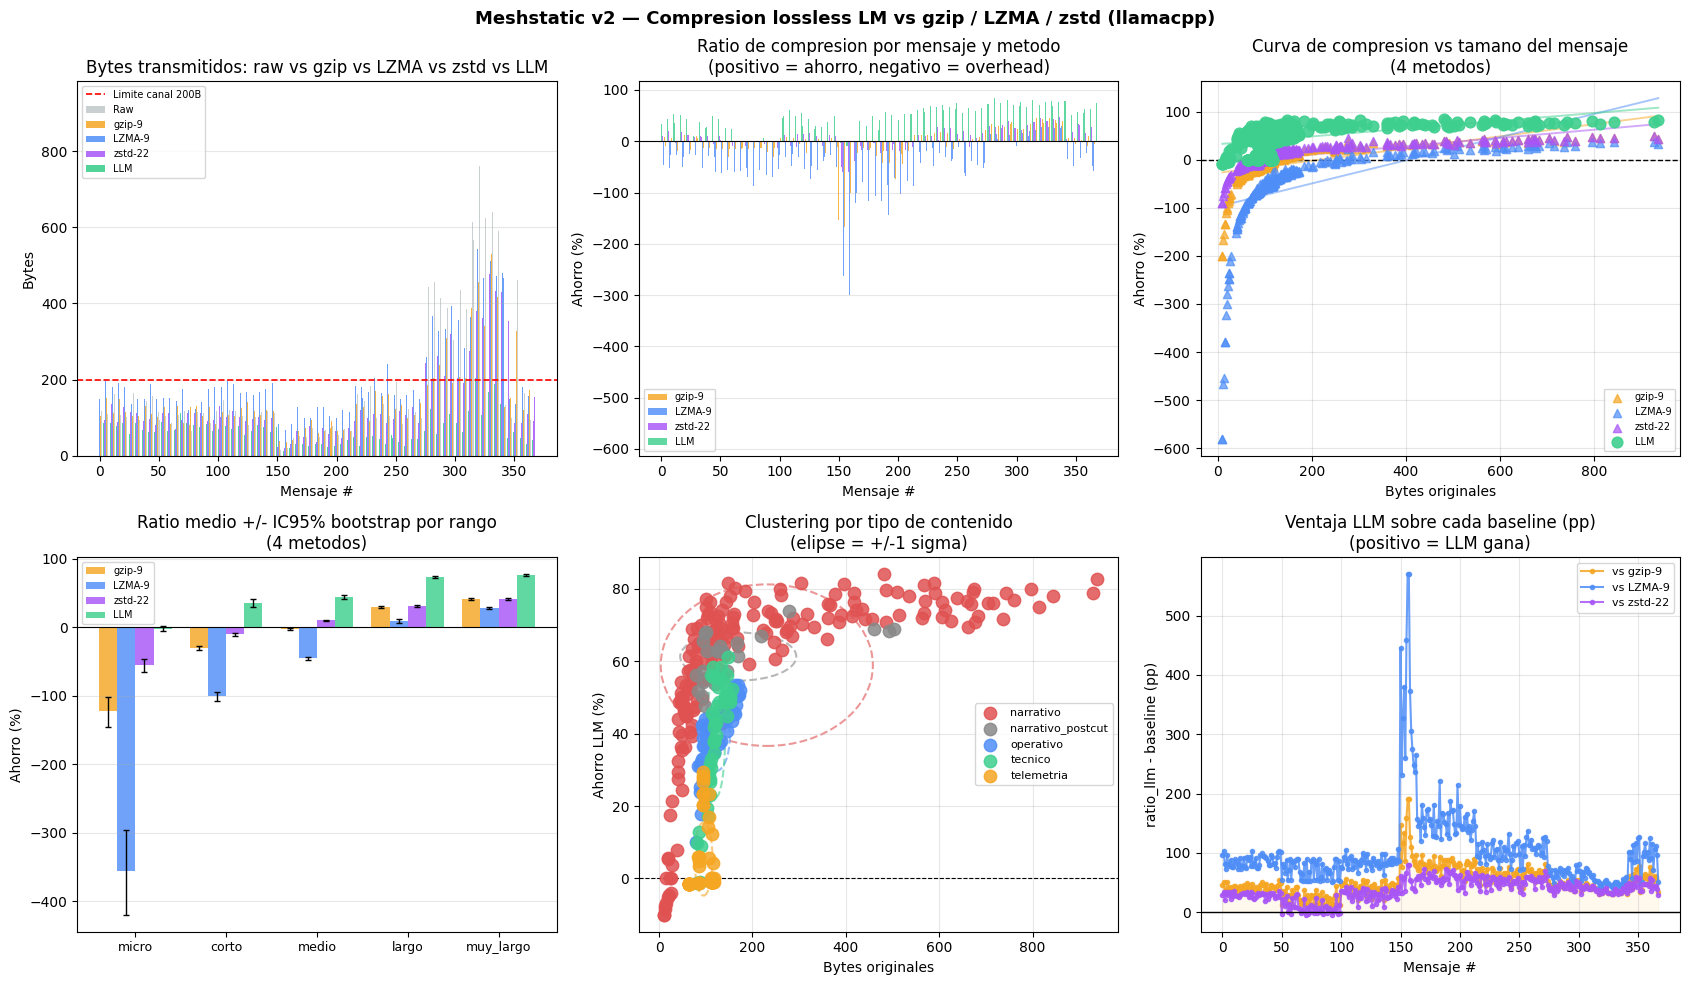

Guardado: metricas_lossless_v2.png
  gzip-9    : media=-5.1%  IC95%=[-8.8%, -1.7%]
  LZMA-9    : media=-54.9%  IC95%=[-63.4%, -47.3%]
  zstd-22   : media=+8.8%  IC95%=[+6.6%, +11.0%]
  LLM       : media=+46.4%  IC95%=[+43.7%, +49.1%]


In [10]:
if df_ok.empty:
    print('Sin datos. Revisa los errores anteriores.')
else:
    COLORES_RANGO = {
        'micro':    '#a855f7', 'corto':    '#4f8ef7',
        'medio':    '#3ecf8e', 'largo':    '#f5a623', 'muy_largo':'#e05252',
    }
    COLORES_CAT = {
        'operativo':'#4f8ef7','telemetria':'#f5a623','tecnico':'#3ecf8e','narrativo':'#e05252',
    }
    METODOS  = ['ratio_gzip', 'ratio_lzma', 'ratio_zstd', 'ratio_llm']
    M_LABELS = ['gzip-9',     'LZMA-9',    'zstd-22',    'LLM']
    M_COLORS = ['#f5a623',    '#4f8ef7',   '#a855f7',    '#3ecf8e']

    fig, axes = plt.subplots(2, 3, figsize=(17, 10))
    fig.suptitle(f'Meshstatic v2 — Compresion lossless LM vs gzip / LZMA / zstd ({MODELO_NOMBRE})',
                 fontsize=13, fontweight='bold')

    x = np.arange(len(df_ok))

    # 1. Bytes comparados
    ax = axes[0, 0]
    w = 0.16
    ax.bar(x - 2*w, df_ok['bytes_orig'],  w, label='Raw',     color='#bdc3c7', alpha=0.8)
    ax.bar(x -   w, df_ok['bytes_gzip'],  w, label='gzip-9',  color='#f5a623', alpha=0.85)
    ax.bar(x,       df_ok['bytes_lzma'],  w, label='LZMA-9',  color='#4f8ef7', alpha=0.85)
    ax.bar(x +   w, df_ok['bytes_zstd'],  w, label='zstd-22', color='#a855f7', alpha=0.85)
    ax.bar(x + 2*w, df_ok['bytes_tx'],    w, label='LLM',     color='#3ecf8e', alpha=0.9)
    ax.axhline(200, color='red', linestyle='--', linewidth=1.2, label='Limite canal 200B')
    ax.set_title('Bytes transmitidos: raw vs gzip vs LZMA vs zstd vs LLM')
    ax.set_xlabel('Mensaje #'); ax.set_ylabel('Bytes')
    ax.legend(fontsize=7); ax.grid(axis='y', alpha=0.3)

    # 2. Ratio 4 metodos por mensaje
    ax = axes[0, 1]
    for j, (col, lbl, col_c) in enumerate(zip(METODOS, M_LABELS, M_COLORS)):
        w2 = 0.2
        offset = (j - 1.5) * w2
        ax.bar(x + offset, df_ok[col], w2, label=lbl, color=col_c, alpha=0.82)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title('Ratio de compresion por mensaje y metodo\n(positivo = ahorro, negativo = overhead)')
    ax.set_xlabel('Mensaje #'); ax.set_ylabel('Ahorro (%)')
    ax.legend(fontsize=7); ax.grid(axis='y', alpha=0.3)

    # 3. Breakeven: ratio vs bytes para todos los metodos
    ax = axes[0, 2]
    colors_sc = [COLORES_RANGO.get(r, '#888') for r in df_ok['rango']]
    for col, lbl, col_c in zip(METODOS, M_LABELS, M_COLORS):
        ax.scatter(df_ok['bytes_orig'], df_ok[col], color=col_c, s=35 if col != 'ratio_llm' else 60,
                   alpha=0.7 if col != 'ratio_llm' else 0.9,
                   marker='o' if col == 'ratio_llm' else '^', label=lbl, zorder=3)
        if len(df_ok) > 2:
            z = np.polyfit(df_ok['bytes_orig'], df_ok[col], 1)
            xs = np.linspace(df_ok['bytes_orig'].min(), df_ok['bytes_orig'].max(), 200)
            ax.plot(xs, np.poly1d(z)(xs), color=col_c, linewidth=1.4, alpha=0.5)
    ax.axhline(0, color='black', linewidth=1, linestyle='--')
    ax.set_title('Curva de compresion vs tamano del mensaje\n(4 metodos)')
    ax.set_xlabel('Bytes originales'); ax.set_ylabel('Ahorro (%)')
    ax.legend(fontsize=7); ax.grid(alpha=0.3)

    # 4. Ratio medio + CI bootstrap por rango (4 metodos)
    ax = axes[1, 0]
    orden_r = [r for r in ['micro','corto','medio','largo','muy_largo'] if r in df_ok['rango'].values]
    xr = np.arange(len(orden_r))
    w3 = 0.2
    for j, (col, lbl, col_c) in enumerate(zip(METODOS, M_LABELS, M_COLORS)):
        means, elo, ehi = [], [], []
        for r in orden_r:
            vals = df_ok[df_ok['rango'] == r][col].dropna().values
            mu = float(np.mean(vals)) if len(vals) else 0
            lo, hi = bootstrap_ci(vals) if len(vals) >= 2 else (mu, mu)
            means.append(mu); elo.append(mu - lo); ehi.append(hi - mu)
        offset = (j - 1.5) * w3
        ax.bar(xr + offset, means, w3, color=col_c, alpha=0.82, label=lbl)
        ax.errorbar(xr + offset, means, yerr=[elo, ehi],
                    fmt='none', color='black', capsize=2.5, linewidth=1)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xticks(xr); ax.set_xticklabels(orden_r, fontsize=9)
    ax.set_title('Ratio medio +/- IC95% bootstrap por rango\n(4 metodos)')
    ax.set_ylabel('Ahorro (%)'); ax.legend(fontsize=7); ax.grid(axis='y', alpha=0.3)

    # 5. Clustering por categoria
    ax = axes[1, 1]
    for cat, grp in df_ok.groupby('categoria'):
        c = COLORES_CAT.get(cat, '#888')
        ax.scatter(grp['bytes_orig'], grp['ratio_llm'], c=c, s=80, alpha=0.85, label=cat, zorder=3)
        if len(grp) > 1:
            mx, my = grp['bytes_orig'].mean(), grp['ratio_llm'].mean()
            sx, sy = grp['bytes_orig'].std(),  grp['ratio_llm'].std()
            from matplotlib.patches import Ellipse
            ellipse = Ellipse((mx, my), width=2*sx, height=2*sy,
                              edgecolor=c, facecolor='none', linewidth=1.5, linestyle='--', alpha=0.6)
            ax.add_patch(ellipse)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title('Clustering por tipo de contenido\n(elipse = +/-1 sigma)')
    ax.set_xlabel('Bytes originales'); ax.set_ylabel('Ahorro LLM (%)')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # 6. Ventaja LLM vs cada baseline
    ax = axes[1, 2]
    for col, lbl, col_c in zip(['ratio_gzip','ratio_lzma','ratio_zstd'], ['gzip-9','LZMA-9','zstd-22'], ['#f5a623','#4f8ef7','#a855f7']):
        ventaja = df_ok['ratio_llm'] - df_ok[col]
        ax.plot(x, ventaja, label=f'vs {lbl}', color=col_c, linewidth=1.5, alpha=0.85, marker='o', markersize=3)
    ax.axhline(0, color='black', linewidth=1)
    ax.fill_between(x, 0, df_ok['ratio_llm'] - df_ok['ratio_gzip'],
                    alpha=0.08, color='#f5a623')
    ax.set_title('Ventaja LLM sobre cada baseline (pp)\n(positivo = LLM gana)')
    ax.set_xlabel('Mensaje #'); ax.set_ylabel('ratio_llm - baseline (pp)')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('metricas_lossless_v2.png', dpi=130, bbox_inches='tight')
    plt.show()
    print('Guardado: metricas_lossless_v2.png')

    for col, lbl in zip(METODOS, M_LABELS):
        vals = df_ok[col]
        lo, hi = bootstrap_ci(vals.values)
        print(f'  {lbl:10s}: media={vals.mean():+.1f}%  IC95%=[{lo:+.1f}%, {hi:+.1f}%]')

## 6. Tiempo en el aire LoRa

LoRa tiene velocidades de datos muy bajas. El tiempo en el aire es el tiempo que ocupa el canal de radio.

| SF | Velocidad útil | Uso típico |
|---|---|---|
| SF7  | ~5.5 kbps | Corto alcance, máxima velocidad |
| SF10 | ~0.98 kbps | Alcance medio, equilibrio |
| SF12 | ~0.29 kbps | Máximo alcance, mínima velocidad |

Tiempo en el aire promedio por SF (todos los mensajes)

SF     bps      Raw (ms)     gzip (ms)    LLM (ms)     Ahorro vs raw  
-----------------------------------------------------------------
SF7        5469       260.6ms       215.9ms       102.5ms       +158.1ms
SF10        977      1458.7ms      1208.3ms       573.6ms       +885.1ms
SF12        293      4864.1ms      4029.2ms      1912.7ms      +2951.4ms


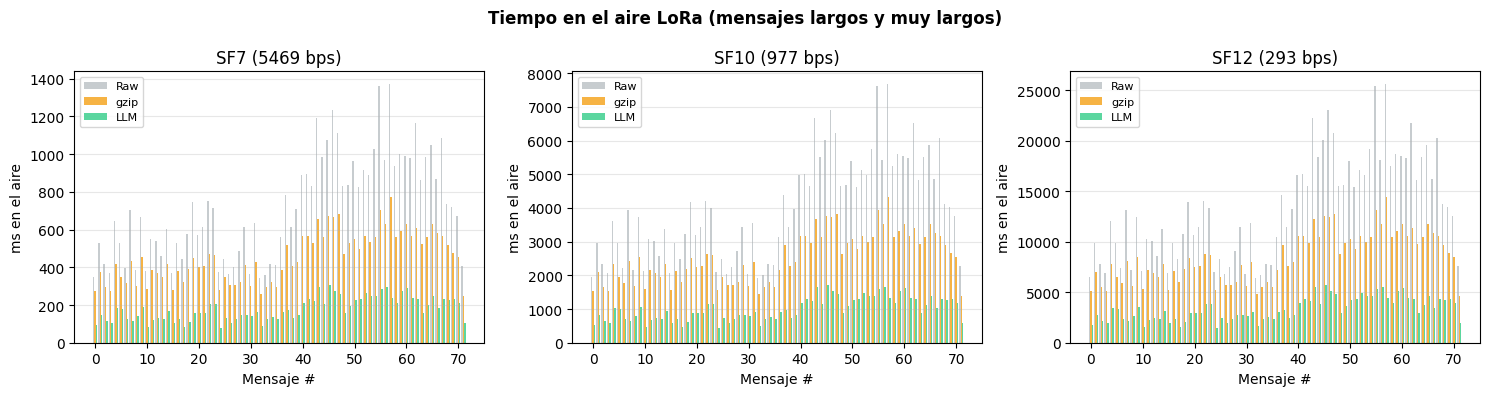

Guardado: toa_lora.png


In [11]:
LORA_SF = {
    'SF7':  5469,
    'SF10':  977,
    'SF12':  293,
}

def toa_ms(n_bytes, bps):
    return (n_bytes * 8 / bps) * 1000

if not df_ok.empty:
    lora_rows = []
    for sf, bps in LORA_SF.items():
        for _, row in df_ok.iterrows():
            toa_raw  = toa_ms(row['bytes_orig'], bps)
            toa_gzip = toa_ms(row['bytes_gzip'], bps)
            toa_llm  = toa_ms(row['bytes_tx'],   bps)
            lora_rows.append({
                'sf': sf, 'bps': bps,
                'rango': row['rango'],
                'bytes_orig': row['bytes_orig'],
                'toa_raw_ms':  toa_raw,
                'toa_gzip_ms': toa_gzip,
                'toa_llm_ms':  toa_llm,
                'ahorro_vs_raw_ms':  toa_raw  - toa_llm,
                'ahorro_vs_gzip_ms': toa_gzip - toa_llm,
            })
    df_lora = pd.DataFrame(lora_rows)

    print('Tiempo en el aire promedio por SF (todos los mensajes)\n')
    print(f'{"SF":6s} {"bps":8s} {"Raw (ms)":12s} {"gzip (ms)":12s} {"LLM (ms)":12s} {"Ahorro vs raw":15s}')
    print('-' * 65)
    for sf, bps in LORA_SF.items():
        sub = df_lora[df_lora['sf'] == sf]
        print(f'{sf:6s} {bps:8d} '
              f'{sub["toa_raw_ms"].mean():11.1f}ms '
              f'{sub["toa_gzip_ms"].mean():11.1f}ms '
              f'{sub["toa_llm_ms"].mean():11.1f}ms '
              f'{sub["ahorro_vs_raw_ms"].mean():+12.1f}ms')

    # Grafico ToA para mensajes largos
    df_lora_largo = df_lora[df_lora['rango'].isin(['largo', 'muy_largo'])]
    if not df_lora_largo.empty:
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        fig.suptitle('Tiempo en el aire LoRa (mensajes largos y muy largos)',
                     fontsize=12, fontweight='bold')
        for ax, (sf, bps) in zip(axes, LORA_SF.items()):
            sub = df_lora_largo[df_lora_largo['sf'] == sf].reset_index(drop=True)
            xi = np.arange(len(sub))
            w  = 0.27
            ax.bar(xi - w, sub['toa_raw_ms'],  w, label='Raw',  color='#bdc3c7', alpha=0.85)
            ax.bar(xi,     sub['toa_gzip_ms'], w, label='gzip', color='#f5a623', alpha=0.85)
            ax.bar(xi + w, sub['toa_llm_ms'],  w, label='LLM',  color='#3ecf8e', alpha=0.85)
            ax.set_title(f'{sf} ({bps} bps)')
            ax.set_xlabel('Mensaje #')
            ax.set_ylabel('ms en el aire')
            ax.legend(fontsize=8)
            ax.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.savefig('toa_lora.png', dpi=120, bbox_inches='tight')
        plt.show()
        print('Guardado: toa_lora.png')


## 7. Costos de procesamiento

El LM tiene un costo computacional que gzip no tiene: hay que correr inferencia por cada token.

- **encode_ms**: tiempo que tardó el nodo **emisor** en comprimir el mensaje (inferencia LM token a token).
- **decode_ms**: tiempo que tardó el nodo **receptor** en descomprimir (mismo proceso: el receptor necesita el mismo número de inferencias).
- **ms/token**: eficiencia del LM por token — cuánto cuesta predistribuir un token. Idealmente constante independiente del tamaño del mensaje.

### ¿Vale la pena computacionalmente?

Para radio LoRa, la variable clave es el **tiempo total de ocupación del canal** = tiempo en el aire. Si encode + decode + ToA_LLM < ToA_raw, el sistema gana incluso considerando el costo computacional.

**Nota**: `encode_ms ≈ decode_ms` porque ambos nodos ejecutan el mismo número de inferencias LM. Las diferencias pequeñas se deben a overhead de red y overhead de escritura en el receptor.

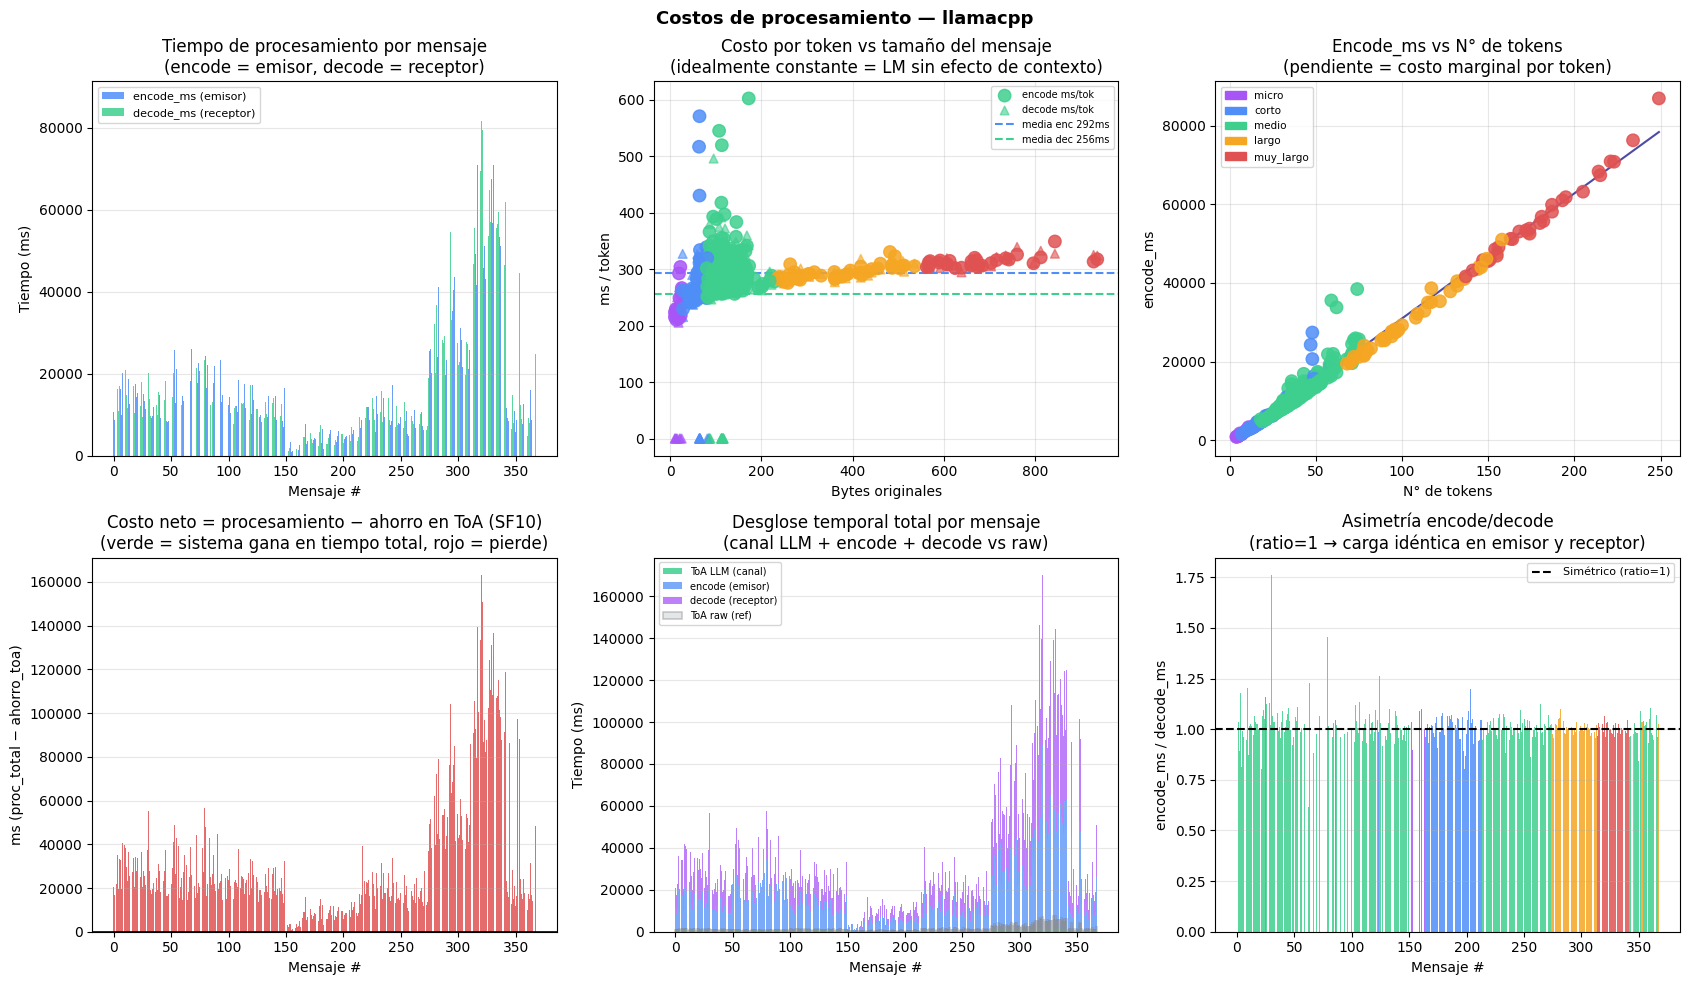

Guardado: costos_procesamiento.png

=== Resumen de costos de procesamiento ===
  encode_ms media   :   17104 ms
  decode_ms media   :   15195 ms
  ms/token  encode  :     292 ms/tok
  ms/token  decode  :     256 ms/tok
  Costo neto medio  :  +31414 ms  (negativo = el LM conviene en tiempo total a SF10)
  Mensajes donde el procesamiento se amortiza: 0/368


In [12]:
if df_ok.empty or df_ok['encode_ms'].sum() == 0:
    print('Sin datos de encode_ms/decode_ms. Asegurate de usar el servidor actualizado.')
else:
    COLORES_RANGO = {
        'micro':    '#a855f7',
        'corto':    '#4f8ef7',
        'medio':    '#3ecf8e',
        'largo':    '#f5a623',
        'muy_largo':'#e05252',
    }
    LORA_SF = {'SF7': 5469, 'SF10': 977, 'SF12': 293}

    df_t = df_ok[df_ok['encode_ms'] > 0].copy()
    df_t['ms_por_tok_enc'] = df_t['encode_ms'] / df_t['n_tokens'].replace(0, np.nan)
    df_t['ms_por_tok_dec'] = df_t['decode_ms'] / df_t['n_tokens'].replace(0, np.nan)
    df_t['proc_total_ms'] = df_t['encode_ms'] + df_t['decode_ms']

    # ToA LLM y ToA raw a SF10 para calcular beneficio neto
    BPS_SF10 = LORA_SF['SF10']
    df_t['toa_raw_ms']  = df_t['bytes_orig'] * 8 / BPS_SF10 * 1000
    df_t['toa_llm_ms']  = df_t['bytes_tx']   * 8 / BPS_SF10 * 1000
    df_t['ahorro_toa']  = df_t['toa_raw_ms'] - df_t['toa_llm_ms']
    df_t['costo_neto']  = df_t['proc_total_ms'] - df_t['ahorro_toa']
    # costo_neto < 0 → el ahorro en ToA supera el costo de procesamiento

    fig, axes = plt.subplots(2, 3, figsize=(17, 10))
    fig.suptitle(f'Costos de procesamiento — {MODELO_NOMBRE}', fontsize=13, fontweight='bold')

    colors_rango = [COLORES_RANGO.get(r, '#888') for r in df_t['rango']]
    x = np.arange(len(df_t))

    # 1. Encode vs Decode ms por mensaje
    ax = axes[0, 0]
    w = 0.35
    ax.bar(x - w/2, df_t['encode_ms'], w, label='encode_ms (emisor)', color='#4f8ef7', alpha=0.85)
    ax.bar(x + w/2, df_t['decode_ms'], w, label='decode_ms (receptor)', color='#3ecf8e', alpha=0.85)
    ax.set_title('Tiempo de procesamiento por mensaje\n(encode = emisor, decode = receptor)')
    ax.set_xlabel('Mensaje #')
    ax.set_ylabel('Tiempo (ms)')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

    # 2. ms/token — debería ser aproximadamente constante
    ax = axes[0, 1]
    ax.scatter(df_t['bytes_orig'], df_t['ms_por_tok_enc'], c=colors_rango, s=80, alpha=0.85,
               label='encode ms/tok', zorder=3)
    ax.scatter(df_t['bytes_orig'], df_t['ms_por_tok_dec'], c=colors_rango, s=40, alpha=0.6,
               marker='^', label='decode ms/tok', zorder=2)
    media_enc = df_t['ms_por_tok_enc'].mean()
    media_dec = df_t['ms_por_tok_dec'].mean()
    ax.axhline(media_enc, color='#4f8ef7', linewidth=1.5, linestyle='--',
               label=f'media enc {media_enc:.0f}ms')
    ax.axhline(media_dec, color='#3ecf8e', linewidth=1.5, linestyle='--',
               label=f'media dec {media_dec:.0f}ms')
    ax.set_title('Costo por token vs tamaño del mensaje\n(idealmente constante = LM sin efecto de contexto)')
    ax.set_xlabel('Bytes originales')
    ax.set_ylabel('ms / token')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

    # 3. Escala de procesamiento: ms total vs n_tokens
    ax = axes[0, 2]
    ax.scatter(df_t['n_tokens'], df_t['encode_ms'], c=colors_rango, s=80, alpha=0.85, zorder=3)
    if len(df_t) > 2:
        z = np.polyfit(df_t['n_tokens'], df_t['encode_ms'], 1)
        xs = np.linspace(df_t['n_tokens'].min(), df_t['n_tokens'].max(), 100)
        ax.plot(xs, np.poly1d(z)(xs), 'navy', linewidth=1.5, alpha=0.7,
                label=f'~{z[0]:.0f} ms/token')
    patches_r = [mpatches.Patch(color=v, label=k) for k, v in COLORES_RANGO.items()
                 if k in df_t['rango'].values]
    ax.legend(handles=patches_r, fontsize=7.5)
    ax.set_title('Encode_ms vs N° de tokens\n(pendiente = costo marginal por token)')
    ax.set_xlabel('N° de tokens')
    ax.set_ylabel('encode_ms')
    ax.grid(alpha=0.3)

    # 4. Costo vs ahorro en el canal (SF10)
    ax = axes[1, 0]
    colors_net = ['#3ecf8e' if v < 0 else '#e05252' for v in df_t['costo_neto']]
    ax.bar(x, df_t['costo_neto'], color=colors_net, alpha=0.85)
    ax.axhline(0, color='black', linewidth=1.2)
    ax.set_title('Costo neto = procesamiento − ahorro en ToA (SF10)\n(verde = sistema gana en tiempo total, rojo = pierde)')
    ax.set_xlabel('Mensaje #')
    ax.set_ylabel('ms (proc_total − ahorro_toa)')
    ax.grid(axis='y', alpha=0.3)

    # 5. Desglose temporal por mensaje (apilado)
    ax = axes[1, 1]
    ax.bar(x, df_t['toa_llm_ms'], label='ToA LLM (canal)',    color='#3ecf8e', alpha=0.85)
    ax.bar(x, df_t['encode_ms'],  bottom=df_t['toa_llm_ms'],
           label='encode (emisor)',  color='#4f8ef7', alpha=0.75)
    ax.bar(x, df_t['decode_ms'],  bottom=df_t['toa_llm_ms'] + df_t['encode_ms'],
           label='decode (receptor)', color='#a855f7', alpha=0.75)
    ax.bar(x, df_t['toa_raw_ms'], label='ToA raw (ref)',       color='#bdc3c7', alpha=0.4,
           linewidth=1.2, edgecolor='gray')
    ax.set_title('Desglose temporal total por mensaje\n(canal LLM + encode + decode vs raw)')
    ax.set_xlabel('Mensaje #')
    ax.set_ylabel('Tiempo (ms)')
    ax.legend(fontsize=7)
    ax.grid(axis='y', alpha=0.3)

    # 6. Ratio encode/decode — ¿son simétricas las cargas?
    ax = axes[1, 2]
    ratio_sym = df_t['encode_ms'] / df_t['decode_ms'].replace(0, np.nan)
    ax.bar(x, ratio_sym, color=colors_rango, alpha=0.85)
    ax.axhline(1.0, color='black', linewidth=1.5, linestyle='--', label='Simétrico (ratio=1)')
    ax.set_title('Asimetría encode/decode\n(ratio=1 → carga idéntica en emisor y receptor)')
    ax.set_xlabel('Mensaje #')
    ax.set_ylabel('encode_ms / decode_ms')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig('costos_procesamiento.png', dpi=130, bbox_inches='tight')
    plt.show()
    print('Guardado: costos_procesamiento.png')

    # Tabla resumen de costos
    print('\n=== Resumen de costos de procesamiento ===')
    print(f'  encode_ms media   : {df_t["encode_ms"].mean():7.0f} ms')
    print(f'  decode_ms media   : {df_t["decode_ms"].mean():7.0f} ms')
    print(f'  ms/token  encode  : {df_t["ms_por_tok_enc"].mean():7.0f} ms/tok')
    print(f'  ms/token  decode  : {df_t["ms_por_tok_dec"].mean():7.0f} ms/tok')
    print(f'  Costo neto medio  : {df_t["costo_neto"].mean():+7.0f} ms  (negativo = el LM conviene en tiempo total a SF10)')
    gana = (df_t['costo_neto'] < 0).sum()
    print(f'  Mensajes donde el procesamiento se amortiza: {gana}/{len(df_t)}')

## 7. Tabla resumen

In [13]:
if not df_ok.empty:
    df_lossless = df_ok[df_ok['encoding'].str.contains('lossless/lossless', na=False)]
    df_raw_fb   = df_ok[df_ok['encoding'].str.contains('lossless/raw', na=False)]

    resumen = pd.DataFrame([
        ('Mensajes evaluados',          len(df)),
        ('Errores de transmision',      int(df['error'].notna().sum())),
        ('Lossless verificados (100%)', f'{int(df_ok["lossless_ok"].sum())}/{len(df_ok)}'),
        ('Modo lossless (comprimido)',  f'{len(df_lossless)} msgs ({100*len(df_lossless)/max(len(df_ok),1):.0f}%)'),
        ('Modo raw fallback',           f'{len(df_raw_fb)} msgs ({100*len(df_raw_fb)/max(len(df_ok),1):.0f}%)'),
        ('', ''),
        ('RATIO LLM — media',           f'{df_ok["ratio_llm"].mean():.1f}%'),
        ('RATIO LLM — max',             f'{df_ok["ratio_llm"].max():.1f}%'),
        ('RATIO LLM — min',             f'{df_ok["ratio_llm"].min():.1f}%'),
        ('RATIO gzip — media',          f'{df_ok["ratio_gzip"].mean():.1f}%'),
        ('', ''),
        ('Bytes originales (media)',    f'{df_ok["bytes_orig"].mean():.0f} B'),
        ('Bytes TX LLM (media)',        f'{df_ok["bytes_tx"].mean():.0f} B'),
        ('Bytes TX gzip (media)',       f'{df_ok["bytes_gzip"].mean():.0f} B'),
        ('Ahorro LLM promedio',         f'{(df_ok["bytes_orig"] - df_ok["bytes_tx"]).mean():.0f} B'),
        ('', ''),
        ('Latencia encoding (media)',   f'{df_ok["latencia_ms"].mean()/1000:.1f} s'),
        ('Latencia encoding (max)',     f'{df_ok["latencia_ms"].max()/1000:.1f} s'),
    ], columns=['Metrica', 'Valor'])

    display(resumen.style.hide(axis='index'))


Metrica,Valor
Mensajes evaluados,368
Errores de transmision,0
Lossless verificados (100%),366/368
Modo lossless (comprimido),329 msgs (89%)
Modo raw fallback,39 msgs (11%)
,
RATIO LLM — media,46.4%
RATIO LLM — max,84.0%
RATIO LLM — min,-10.0%
RATIO gzip — media,-5.1%


## 8. Detalle por rango de tamaño

In [14]:
if not df_ok.empty:
    orden = ['micro', 'corto', 'medio', 'largo', 'muy_largo']
    rows = []
    for r in [x for x in orden if x in df_ok['rango'].values]:
        sub = df_ok[df_ok['rango'] == r]
        def ci_str(col):
            vals = sub[col].dropna().values
            if len(vals) < 2: return f'{np.mean(vals):.1f} (n<2)'
            lo, hi = bootstrap_ci(vals)
            return f'{np.mean(vals):.1f} [{lo:.1f}, {hi:.1f}]'
        rows.append({
            'Rango':           r,
            'N':               len(sub),
            'Bytes orig':      f'{sub["bytes_orig"].mean():.0f}',
            'LLM% [IC95%]':   ci_str('ratio_llm'),
            'gzip% [IC95%]':  ci_str('ratio_gzip'),
            'LZMA% [IC95%]':  ci_str('ratio_lzma'),
            'zstd% [IC95%]':  ci_str('ratio_zstd'),
            'Lossless%':       f'{100*sub["lossless_ok"].mean():.0f}',
        })
    display(pd.DataFrame(rows))

    print('\nPor tipo de contenido:')
    rows_cat = []
    for cat in df_ok['categoria'].unique():
        sub = df_ok[df_ok['categoria'] == cat]
        lo, hi = bootstrap_ci(sub['ratio_llm'].values) if len(sub) >= 2 else (0, 0)
        rows_cat.append({
            'Categoria':  cat,
            'N':          len(sub),
            'LLM media':  f'{sub["ratio_llm"].mean():.1f}',
            'IC95%':      f'[{lo:.1f}, {hi:.1f}]',
            'gzip media': f'{sub["ratio_gzip"].mean():.1f}',
            'LZMA media': f'{sub["ratio_lzma"].mean():.1f}',
            'zstd media': f'{sub["ratio_zstd"].mean():.1f}',
            'Bytes prom': f'{sub["bytes_orig"].mean():.0f}',
        })
    display(pd.DataFrame(rows_cat).sort_values('LLM media', ascending=False))

,Rango,N,Bytes orig,LLM% [IC95%],gzip% [IC95%],LZMA% [IC95%],zstd% [IC95%],Lossless%
0,micro,14,18,"-2.0 [-5.5, 1.7]","-122.8 [-145.0, -101.6]","-355.3 [-419.3, -296.0]","-55.5 [-65.4, -46.2]",100
1,corto,66,61,"35.6 [30.3, 41.1]","-30.7 [-33.5, -28.0]","-100.8 [-107.8, -94.3]","-10.5 [-12.4, -8.5]",100
2,medio,216,121,"43.7 [40.6, 46.7]","-2.6 [-4.0, -1.1]","-45.2 [-47.3, -43.2]","10.1 [8.9, 11.2]",100
3,largo,44,361,"72.8 [71.3, 74.3]","29.3 [27.5, 31.1]","9.4 [6.5, 12.2]","31.6 [30.1, 33.0]",100
4,muy_largo,28,686,"76.1 [74.8, 77.5]","40.8 [39.3, 42.3]","28.0 [26.3, 30.0]","41.0 [39.7, 42.4]",96



Por tipo de contenido:


,Categoria,N,LLM media,IC95%,gzip media,LZMA media,zstd media,Bytes prom
4,narrativo_postcut,26,61.3,"[58.7, 63.6]",5.1,-33.6,16.1,170
3,narrativo,192,58.9,"[55.8, 62.1]",-4.1,-59.6,10.2,231
1,telemetria,50,5.4,"[2.7, 8.2]",-18.5,-65.2,-2.3,95
0,operativo,50,39.3,"[36.5, 42.0]",-3.0,-46.8,10.3,121
2,tecnico,50,39.1,"[34.4, 43.4]",-2.9,-45.3,9.4,121


## 11. Analisis estadistico

Intervalos de confianza bootstrap (95%, n_boot=2000), tests de hipotesis no parametricos
y comparacion de los cuatro metodos: **LLM**, **gzip-9**, **LZMA-9**, **zstd-22**.

- **Bootstrap CI**: sin asunciones de normalidad, apropiado para n pequeno.
- **Kruskal-Wallis**: diferencias entre grupos de tamano (no parametrico).
- **Wilcoxon signed-rank**: comparacion pareada LLM vs cada baseline (mismo mensaje).
- **Spearman rho**: correlacion monotona bytes-orig vs ratio.
- **CDF**: fraccion de mensajes que superan cada umbral de ahorro.
- **Ganador por mensaje**: que metodo da el mayor ratio en cada mensaje individual.

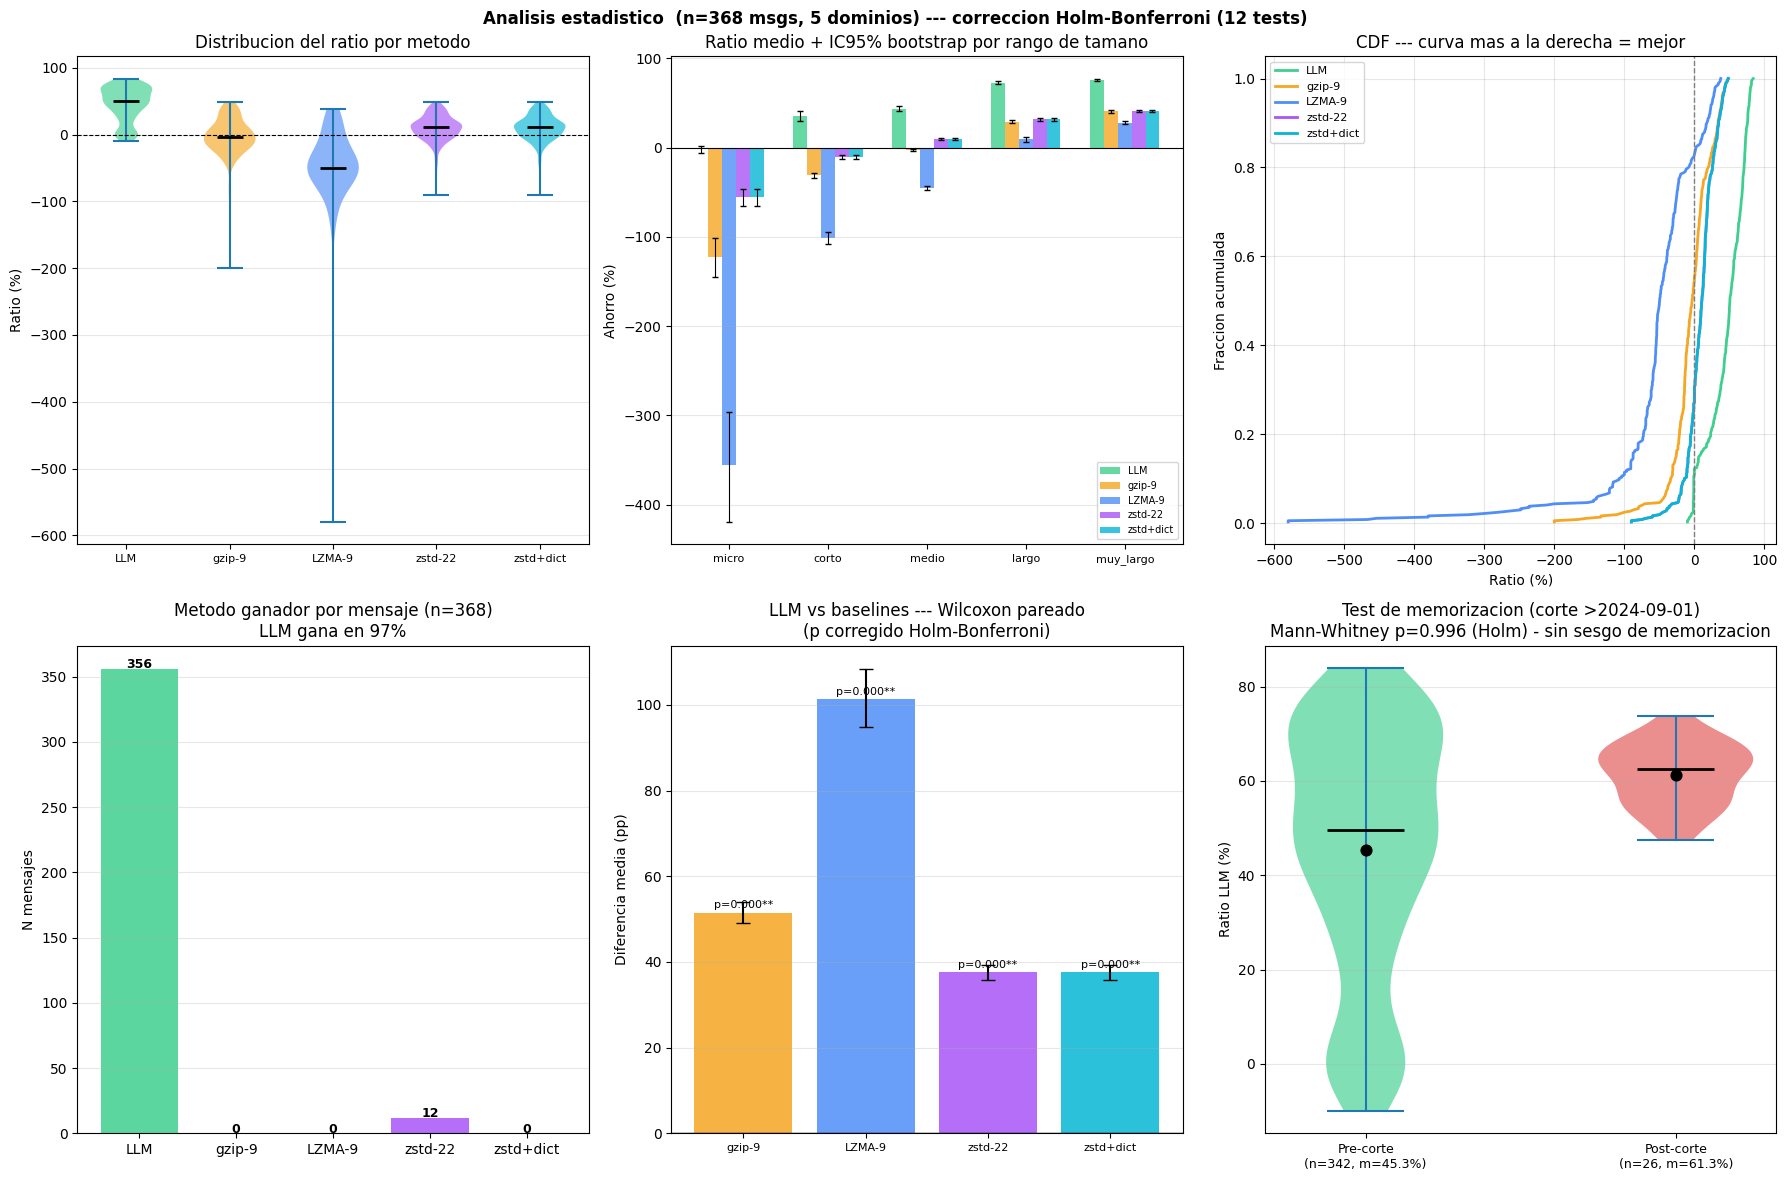

Guardado: stats_comparison.png

=== Correccion Holm-Bonferroni (12 tests simultaneos) ===
  P(al menos 1 falso positivo) <= 0.05 globalmente
Test                                             p crudo    p Holm     Sig     
--------------------------------------------------------------------------------
Spearman: LZMA-9                                 0.0000     0.0000     ** p<0.01
Spearman: gzip-9                                 0.0000     0.0000     ** p<0.01
Spearman: zstd-22                                0.0000     0.0000     ** p<0.01
Spearman: zstd+dict                              0.0000     0.0000     ** p<0.01
Wilcoxon: LLM vs gzip-9                          0.0000     0.0000     ** p<0.01
Wilcoxon: LLM vs LZMA-9                          0.0000     0.0000     ** p<0.01
Wilcoxon: LLM vs zstd-22                         0.0000     0.0000     ** p<0.01
Wilcoxon: LLM vs zstd+dict                       0.0000     0.0000     ** p<0.01
Spearman: LLM                                    0

In [15]:
if df_ok.empty:
    print('Sin datos - ejecuta cell-enviar primero.')
else:
    METODOS = ['ratio_llm', 'ratio_gzip', 'ratio_lzma', 'ratio_zstd', 'ratio_zstd_dict']
    LABELS  = ['LLM', 'gzip-9', 'LZMA-9', 'zstd-22', 'zstd+dict']
    COLORS  = ['#3ecf8e', '#f5a623', '#4f8ef7', '#a855f7', '#06b6d4']
    ORDEN   = [r for r in ['micro','corto','medio','largo','muy_largo']
               if r in df_ok['rango'].values]
    # Filtrar columnas que existan (ejecucion parcial o sin dict)
    METODOS = [m for m in METODOS if m in df_ok.columns]
    LABELS  = LABELS[:len(METODOS)]
    COLORS  = COLORS[:len(METODOS)]

    # === Holm-Bonferroni =====================================================
    def holm_bonferroni(pvals):
        # Holm (1979) step-down. Controla FWER; mas potente que Bonferroni simple.
        n   = len(pvals)
        arr = np.asarray(pvals, dtype=float)
        idx = np.argsort(arr)
        corrected = np.zeros(n)
        running_max = 0.0
        for rank_i, orig_i in enumerate(idx):
            adj = min(1.0, arr[orig_i] * (n - rank_i))
            running_max = max(running_max, adj)
            corrected[orig_i] = running_max
        return corrected

    # === Tests de hipotesis ==================================================
    all_pvals = {}

    # A. Kruskal-Wallis: LLM varia entre rangos de tamano?
    groups_kw = [df_ok[df_ok['rango']==r]['ratio_llm'].dropna().values
                 for r in ORDEN if (df_ok['rango']==r).sum() > 0]
    kw_stat, kw_p = sp_stats.kruskal(*groups_kw) if len(groups_kw) >= 2 else (0.0, 1.0)
    all_pvals['KW: LLM por tamano'] = float(kw_p)

    # B. Wilcoxon pareado: LLM vs cada baseline
    wx_results = {}
    for m, lbl in zip(METODOS[1:], LABELS[1:]):
        diffs = df_ok['ratio_llm'].values - df_ok[m].values
        try:
            _, p_w = sp_stats.wilcoxon(diffs, zero_method='zsplit')
        except Exception:
            p_w = 1.0
        all_pvals[f'Wilcoxon: LLM vs {lbl}'] = float(p_w)
        lo, hi = bootstrap_ci(diffs)
        wx_results[lbl] = {'mu': float(np.mean(diffs)), 'lo': lo, 'hi': hi, 'col': m}

    # C. Spearman: bytes_orig vs ratio
    spearman_res = {}
    for m, lbl in zip(METODOS, LABELS):
        rho, p_rho = sp_stats.spearmanr(df_ok['bytes_orig'], df_ok[m])
        all_pvals[f'Spearman: {lbl}'] = float(p_rho)
        spearman_res[lbl] = (float(rho), float(p_rho))

    # D. Mann-Whitney: pre-cutoff vs post-cutoff (test de memorizacion)
    _mc = MODEL_CUTOFF if 'MODEL_CUTOFF' in dir() else '2024-09-01'
    df_pre  = df_ok[df_ok['categoria'] != 'narrativo_postcut']
    df_post = df_ok[df_ok['categoria'] == 'narrativo_postcut']
    has_mem_data = len(df_post) >= 5 and len(df_pre) >= 5
    if has_mem_data:
        _, p_mw = sp_stats.mannwhitneyu(
            df_pre['ratio_llm'].values, df_post['ratio_llm'].values,
            alternative='greater')
        all_pvals['Mann-Whitney: pre vs post-cutoff'] = float(p_mw)

    # E. Kruskal-Wallis entre dominios
    dom_cats = [d for d in ['operativo','telemetria','tecnico','narrativo','narrativo_postcut']
                if (df_ok['categoria']==d).sum() >= 3]
    if len(dom_cats) >= 2:
        groups_dom = [df_ok[df_ok['categoria']==d]['ratio_llm'].values for d in dom_cats]
        _, kw2_p = sp_stats.kruskal(*groups_dom)
        all_pvals['KW: LLM por dominio'] = float(kw2_p)

    # Aplicar Holm-Bonferroni
    pval_keys  = list(all_pvals.keys())
    pval_raw   = [all_pvals[k] for k in pval_keys]
    pval_corr  = holm_bonferroni(pval_raw)
    pval_table = {k: (r, c) for k, r, c in zip(pval_keys, pval_raw, pval_corr)}

    # === Figura 1: 6 subplots ================================================
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle(
        f'Analisis estadistico  (n={len(df_ok)} msgs, {len(dom_cats)} dominios) '
        f'--- correccion Holm-Bonferroni ({len(pval_keys)} tests)',
        fontsize=12, fontweight='bold')

    # [0,0] Violines
    ax = axes[0, 0]
    vdata = [df_ok[m].dropna().values for m in METODOS]
    parts = ax.violinplot(vdata, positions=range(len(METODOS)), showmedians=True)
    for pc, col in zip(parts['bodies'], COLORS):
        pc.set_facecolor(col); pc.set_alpha(0.65)
    parts['cmedians'].set_color('black'); parts['cmedians'].set_linewidth(2)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xticks(range(len(METODOS))); ax.set_xticklabels(LABELS, fontsize=8)
    ax.set_ylabel('Ratio (%)'); ax.set_title('Distribucion del ratio por metodo')
    ax.grid(axis='y', alpha=0.3)

    # [0,1] CI bootstrap por rango
    ax = axes[0, 1]
    xr = np.arange(len(ORDEN)); w = 0.14
    for j, (m, lbl, col) in enumerate(zip(METODOS, LABELS, COLORS)):
        means, elo, ehi = [], [], []
        for r in ORDEN:
            vals = df_ok[df_ok['rango']==r][m].dropna().values
            mu = float(np.mean(vals)) if len(vals) else 0
            lo, hi = bootstrap_ci(vals) if len(vals) >= 2 else (mu, mu)
            means.append(mu); elo.append(mu-lo); ehi.append(hi-mu)
        offset = (j - len(METODOS)//2) * w
        ax.bar(xr+offset, means, w, color=col, alpha=0.8, label=lbl)
        ax.errorbar(xr+offset, means, yerr=[elo, ehi],
                    fmt='none', color='black', capsize=2, linewidth=0.8)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xticks(xr); ax.set_xticklabels(ORDEN, fontsize=8)
    ax.set_title('Ratio medio + IC95% bootstrap por rango de tamano')
    ax.set_ylabel('Ahorro (%)'); ax.legend(fontsize=7); ax.grid(axis='y', alpha=0.3)

    # [0,2] CDF
    ax = axes[0, 2]
    for m, lbl, col in zip(METODOS, LABELS, COLORS):
        vals = np.sort(df_ok[m].dropna().values)
        cdf  = np.arange(1, len(vals)+1) / len(vals)
        ax.plot(vals, cdf, color=col, linewidth=2, label=lbl)
    ax.axvline(0, color='gray', linewidth=1, linestyle='--')
    ax.set_xlabel('Ratio (%)'); ax.set_ylabel('Fraccion acumulada')
    ax.set_title('CDF --- curva mas a la derecha = mejor')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # [1,0] Ganador por mensaje
    ax = axes[1, 0]
    winners = df_ok[METODOS].idxmax(axis=1).map(dict(zip(METODOS, LABELS)))
    win_cnt = winners.value_counts().reindex(LABELS, fill_value=0)
    bars = ax.bar(LABELS, win_cnt.values,
                  color=[COLORS[LABELS.index(l)] for l in LABELS], alpha=0.85)
    for bar, v in zip(bars, win_cnt.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                str(v), ha='center', fontsize=9, fontweight='bold')
    pct_llm = 100*win_cnt['LLM']/len(df_ok)
    ax.set_title(f'Metodo ganador por mensaje (n={len(df_ok)})\nLLM gana en {pct_llm:.0f}%')
    ax.set_ylabel('N mensajes'); ax.grid(axis='y', alpha=0.3)

    # [1,1] Wilcoxon LLM vs baselines (p corregido)
    ax = axes[1, 1]
    wx_lbls = list(wx_results.keys())
    for k, lbl in enumerate(wx_lbls):
        res    = wx_results[lbl]
        col_c  = COLORS[LABELS.index(lbl)] if lbl in LABELS else '#888'
        ax.bar(k, res['mu'], color=col_c, alpha=0.85)
        ax.errorbar(k, res['mu'],
                    yerr=[[res['mu']-res['lo']], [res['hi']-res['mu']]],
                    fmt='none', color='black', capsize=5, linewidth=1.5)
        corr_p = pval_table.get(f'Wilcoxon: LLM vs {lbl}', (1.0, 1.0))[1]
        sig_s  = '**' if corr_p < 0.01 else ('*' if corr_p < 0.05 else 'ns')
        y_lbl  = res['mu'] + (1.0 if res['mu'] >= 0 else -2.5)
        ax.text(k, y_lbl, f'p={corr_p:.3f}{sig_s}', ha='center', fontsize=8)
    ax.axhline(0, color='black', linewidth=1)
    ax.set_xticks(range(len(wx_lbls))); ax.set_xticklabels(wx_lbls, fontsize=8)
    ax.set_title('LLM vs baselines --- Wilcoxon pareado\n(p corregido Holm-Bonferroni)')
    ax.set_ylabel('Diferencia media (pp)'); ax.grid(axis='y', alpha=0.3)

    # [1,2] Test de memorizacion
    ax = axes[1, 2]
    if has_mem_data:
        pre_v  = df_pre['ratio_llm'].values
        post_v = df_post['ratio_llm'].values
        vp = ax.violinplot([pre_v, post_v], positions=[0, 1], showmedians=True)
        vp['bodies'][0].set_facecolor('#3ecf8e'); vp['bodies'][0].set_alpha(0.65)
        vp['bodies'][1].set_facecolor('#e05252'); vp['bodies'][1].set_alpha(0.65)
        vp['cmedians'].set_color('black'); vp['cmedians'].set_linewidth(2)
        mu_pre, mu_post = np.mean(pre_v), np.mean(post_v)
        ax.scatter([0,1], [mu_pre, mu_post], color='black', s=60, zorder=5)
        corr_p_mem = pval_table.get('Mann-Whitney: pre vs post-cutoff', (1.0, 1.0))[1]
        verdict = 'sin sesgo de memorizacion' if corr_p_mem >= 0.05 else 'posible sesgo detectado'
        ax.set_xticks([0, 1])
        ax.set_xticklabels([
            f'Pre-corte\n(n={len(pre_v)}, m={mu_pre:.1f}%)',
            f'Post-corte\n(n={len(post_v)}, m={mu_post:.1f}%)'
        ], fontsize=9)
        ax.set_title(f'Test de memorizacion (corte >{_mc})\n'
                     f'Mann-Whitney p={corr_p_mem:.3f} (Holm) - {verdict}')
        ax.set_ylabel('Ratio LLM (%)'); ax.grid(axis='y', alpha=0.3)
    else:
        ax.text(0.5, 0.5,
                f'Post-cutoff: {len(df_post)} fragmentos\n(necesitas >= 5 para el test)',
                ha='center', va='center', transform=ax.transAxes, fontsize=11)
        ax.set_title('Test de memorizacion\n(ejecuta cell-postcutoff primero)')

    plt.tight_layout()
    plt.savefig('stats_comparison.png', dpi=130, bbox_inches='tight')
    plt.show()
    print('Guardado: stats_comparison.png')

    # === Tabla Holm-Bonferroni ================================================
    print(f'\n=== Correccion Holm-Bonferroni ({len(pval_table)} tests simultaneos) ===')
    print(f'  P(al menos 1 falso positivo) <= 0.05 globalmente')
    print(f'{"Test":48s} {"p crudo":10s} {"p Holm":10s} {"Sig":8s}')
    print('-' * 80)
    for k in sorted(pval_table, key=lambda x: pval_table[x][0]):
        raw, corr = pval_table[k]
        sig = '** p<0.01' if corr < 0.01 else ('* p<0.05' if corr < 0.05 else 'ns')
        print(f'{k:48s} {raw:.4f}     {corr:.4f}     {sig}')

    # === Por dominio =========================================================
    print(f'\n=== Ratio LLM por dominio (IC95% bootstrap) ===')
    print(f'{"Dominio":22s} {"N":4s} {"Media":8s} {"IC95%":20s} {"vs gzip":8s} '
          f'{"vs zstd+d":10s}')
    print('-' * 78)
    for cat in sorted(df_ok['categoria'].unique()):
        sub = df_ok[df_ok['categoria'] == cat]
        if len(sub) < 2: continue
        mu = sub['ratio_llm'].mean()
        lo, hi = bootstrap_ci(sub['ratio_llm'].values)
        dg = mu - sub['ratio_gzip'].mean()
        zd_col = 'ratio_zstd_dict' if 'ratio_zstd_dict' in sub.columns else 'ratio_zstd'
        dz = mu - sub[zd_col].mean()
        print(f'{cat:22s} {len(sub):4d} {mu:+7.1f}%  [{lo:+6.1f}%, {hi:+6.1f}%]  '
              f'{dg:+6.1f}pp  {dz:+8.1f}pp')

    # === Spearman con correccion =============================================
    print(f'\n=== Spearman rho (bytes_orig vs ratio) --- p Holm-Bonferroni ===')
    for m, lbl in zip(METODOS, LABELS):
        rho, _ = spearman_res[lbl]
        raw_p  = all_pvals.get(f'Spearman: {lbl}', 1.0)
        corr_p = pval_table.get(f'Spearman: {lbl}', (1.0, 1.0))[1]
        sig = '**' if corr_p < 0.01 else ('*' if corr_p < 0.05 else 'ns')
        print(f'  {lbl:12s}: rho={rho:+.3f}  p_crudo={raw_p:.4f}  p_Holm={corr_p:.4f}  {sig}')


## 9. Densidad de ranks por mensaje

Muestra qué porcentaje de tokens de cada mensaje cae en cada bucket de rank.

| Bucket | Bits usados | Interpretación |
|---|---|---|
| **rank 0** | 1 bit | El modelo predijo exactamente el token correcto |
| **rank 1–3** | 4 bits | Muy alta confianza, top-4 |
| **rank 4–15** | 7 bits | Confianza media, top-16 |
| **rank 16–63** | 10 bits | Confianza baja, top-64 |
| **OOV compacto** | 5 + id_bits bits | Token fuera del top-64 → vocab ID (LlamaCpp, ~23 bits para Qwen 152k vocab) |
| **OOV UTF-8** | 13 + 8L bits | Fallback cuando el backend no expone IDs (Ollama) |

Cuantos más tokens en rank 0 y rank 1–3, mejor predice el modelo y mayor es la compresión.
Un OOV alto indica tokens raros, números, nombres propios, o tokens con gap de entropía insuficiente.

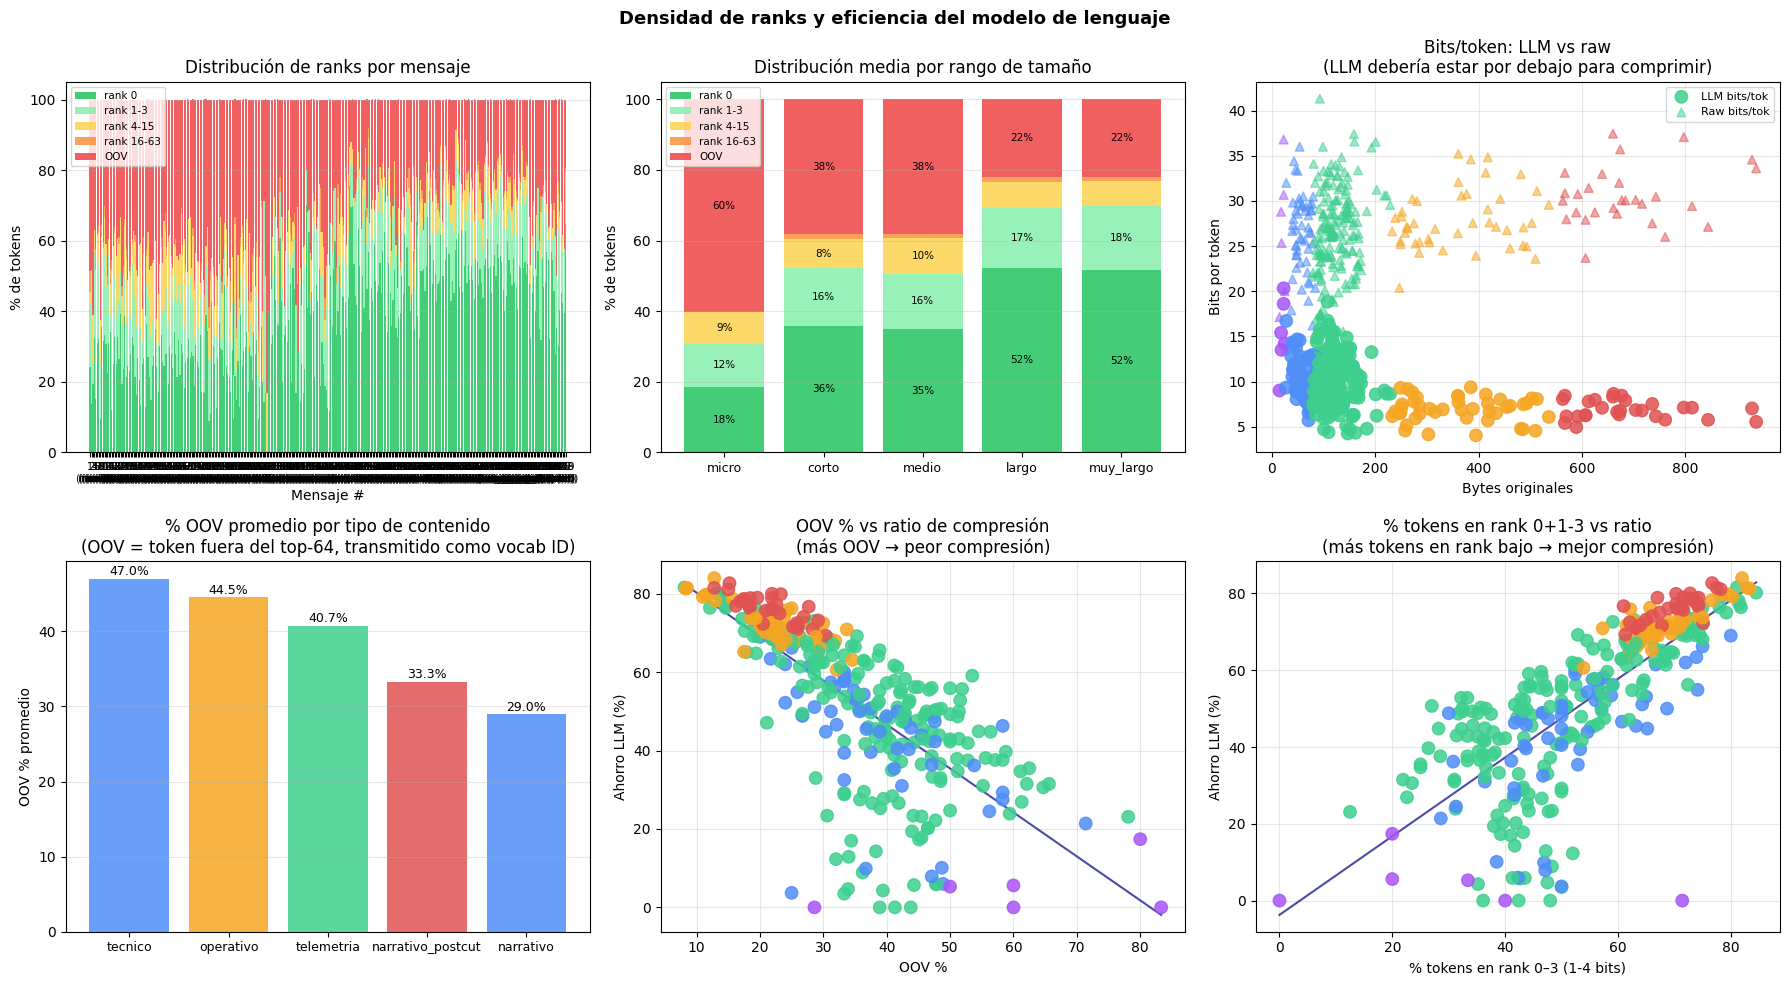

Guardado: rank_density.png

Detalle por mensaje:


,Rango,Cat,B orig,Ratio%,bits/tok LLM,r0%,r1-3%,r4-15%,r16-63%,OOV%
0,medio,operativo,91,33.0,12.9,24.2,18.2,3.0,6.1,48.5
1,medio,operativo,98,43.9,13.2,13.8,24.1,13.8,0.0,48.3
2,medio,operativo,118,34.7,15.4,19.4,5.6,13.9,0.0,61.1
3,medio,operativo,161,46.0,10.3,32.3,24.2,6.5,0.0,37.1
4,medio,operativo,101,41.6,12.4,15.2,21.2,15.2,6.1,42.4
...,...,...,...,...,...,...,...,...,...,...
324,medio,narrativo_postcut,218,67.0,9.0,40.4,22.8,3.5,1.8,31.6
325,medio,narrativo_postcut,94,57.4,8.4,45.2,19.4,6.5,0.0,29.0
326,medio,narrativo_postcut,83,51.8,10.2,42.3,15.4,3.8,0.0,38.5
327,medio,narrativo_postcut,99,47.5,10.9,39.4,18.2,0.0,0.0,42.4



Media global de densidad de ranks:
  rank 0         :  38.5%
  rank 1-3       :  16.1%
  rank 4-15      :   9.1%
  rank 16-63     :   1.2%
  OOV            :  35.0%

  -> Eficiencia: 54.6% de tokens en rank 0+1-3 (bits óptimos)
  -> OOV       : 35.0% de tokens OOV → vocab ID compacto (~23 bits, LlamaCpp)
  -> bits/tok LLM (prom): 9.8 bits/token
  -> bits/tok raw (prom): 26.1 bits/token


In [16]:
# Extraer rank_dist de la respuesta de la API
df_ranks = df_ok[df_ok['rank_dist'].notna()].copy()

if df_ranks.empty:
    print('No hay datos de rank_dist. Verifica que el servidor fue actualizado.')
else:
    rank_cols   = ['r0', 'r1_3', 'r4_15', 'r16_63', 'oov']
    rank_labels = ['rank 0\n(1 bit)', 'rank 1-3\n(4 bits)', 'rank 4-15\n(7 bits)',
                   'rank 16-63\n(10 bits)', 'OOV\n(vocab ID ~23 bits)']
    for col in rank_cols:
        df_ranks[col] = df_ranks['rank_dist'].apply(
            lambda d: d.get(col, 0) if isinstance(d, dict) else 0)

    # Bits promedio por token = suma ponderada de bits por bucket
    BITS_POR_BUCKET = {'r0': 1, 'r1_3': 4, 'r4_15': 7, 'r16_63': 10, 'oov': 23}
    df_ranks['bits_por_tok'] = sum(
        df_ranks[col] / 100 * bits for col, bits in BITS_POR_BUCKET.items()
    )
    df_ranks['bits_raw_por_tok'] = df_ranks.apply(
        lambda r: (r['bytes_orig'] * 8 / r['n_tokens']) if r['n_tokens'] > 0 else 0, axis=1)

    colors = ['#22c55e', '#86efac', '#fcd34d', '#fb923c', '#ef4444']

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Densidad de ranks y eficiencia del modelo de lenguaje', fontsize=13, fontweight='bold')

    # 1. Stacked bar por mensaje
    ax = axes[0, 0]
    bottom = np.zeros(len(df_ranks))
    x = np.arange(len(df_ranks))
    for col, color, lbl in zip(rank_cols, colors, rank_labels):
        vals = df_ranks[col].values
        ax.bar(x, vals, bottom=bottom, color=color, label=lbl.split('\n')[0], alpha=0.85)
        bottom += vals
    ax.set_xlabel('Mensaje #')
    ax.set_ylabel('% de tokens')
    ax.set_title('Distribución de ranks por mensaje')
    ax.legend(fontsize=7.5)
    ax.grid(axis='y', alpha=0.3)
    rango_labels = df_ranks['rango'].values
    ax.set_xticks(x)
    ax.set_xticklabels([f'{i+1}\n({r[:3]})' for i, r in enumerate(rango_labels)], fontsize=7)

    # 2. Media por rango de tamaño
    ax = axes[0, 1]
    orden = ['micro', 'corto', 'medio', 'largo', 'muy_largo']
    por_rango_rd = (
        df_ranks.groupby('rango')[rank_cols].mean()
        .reindex([r for r in orden if r in df_ranks['rango'].values])
    )
    xr = np.arange(len(por_rango_rd))
    bottom2 = np.zeros(len(por_rango_rd))
    for col, color, lbl in zip(rank_cols, colors, rank_labels):
        vals2 = por_rango_rd[col].values
        bars = ax.bar(xr, vals2, bottom=bottom2, color=color, label=lbl.split('\n')[0], alpha=0.85)
        for rect, v in zip(bars, vals2):
            if v > 8:
                ax.text(rect.get_x() + rect.get_width()/2,
                        rect.get_y() + rect.get_height()/2,
                        f'{v:.0f}%', ha='center', va='center', fontsize=7.5, color='black')
        bottom2 += vals2
    ax.set_xticks(xr)
    ax.set_xticklabels(por_rango_rd.index, fontsize=9)
    ax.set_title('Distribución media por rango de tamaño')
    ax.set_ylabel('% de tokens')
    ax.legend(fontsize=7.5)
    ax.grid(axis='y', alpha=0.3)

    # 3. Bits promedio por token: LLM vs raw
    ax = axes[0, 2]
    COLORES_RANGO = {'micro':'#a855f7','corto':'#4f8ef7','medio':'#3ecf8e',
                     'largo':'#f5a623','muy_largo':'#e05252'}
    colors_sc = [COLORES_RANGO.get(r, '#888') for r in df_ranks['rango']]
    ax.scatter(df_ranks['bytes_orig'], df_ranks['bits_por_tok'],
               c=colors_sc, s=80, alpha=0.85, label='LLM bits/tok', zorder=3)
    ax.scatter(df_ranks['bytes_orig'], df_ranks['bits_raw_por_tok'],
               c=colors_sc, s=40, alpha=0.5, marker='^', label='Raw bits/tok', zorder=2)
    ax.set_title('Bits/token: LLM vs raw\n(LLM debería estar por debajo para comprimir)')
    ax.set_xlabel('Bytes originales')
    ax.set_ylabel('Bits por token')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # 4. % OOV por categoria (¿qué tipos generan más OOV?)
    ax = axes[1, 0]
    oov_cat = df_ranks.groupby('categoria')['oov'].mean().sort_values(ascending=False)
    colors_cat = ['#4f8ef7','#f5a623','#3ecf8e','#e05252'][:len(oov_cat)]
    ax.bar(range(len(oov_cat)), oov_cat.values, color=colors_cat, alpha=0.85)
    ax.set_xticks(range(len(oov_cat)))
    ax.set_xticklabels(oov_cat.index, fontsize=9)
    ax.set_title('% OOV promedio por tipo de contenido\n(OOV = token fuera del top-64, transmitido como vocab ID)')
    ax.set_ylabel('OOV % promedio')
    ax.grid(axis='y', alpha=0.3)
    for i, v in enumerate(oov_cat.values):
        ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9)

    # 5. Correlación OOV vs ratio de compresión
    ax = axes[1, 1]
    ax.scatter(df_ranks['oov'], df_ranks['ratio_llm'], c=colors_sc, s=80, alpha=0.85, zorder=3)
    if len(df_ranks) > 2:
        z = np.polyfit(df_ranks['oov'], df_ranks['ratio_llm'], 1)
        xs = np.linspace(df_ranks['oov'].min(), df_ranks['oov'].max(), 100)
        ax.plot(xs, np.poly1d(z)(xs), 'navy', linewidth=1.5, alpha=0.7)
    ax.set_title('OOV % vs ratio de compresión\n(más OOV → peor compresión)')
    ax.set_xlabel('OOV %')
    ax.set_ylabel('Ahorro LLM (%)')
    ax.grid(alpha=0.3)

    # 6. Eficiencia: % en rank 0 + rank1-3 vs ratio
    ax = axes[1, 2]
    df_ranks['top4_pct'] = df_ranks['r0'] + df_ranks['r1_3']
    ax.scatter(df_ranks['top4_pct'], df_ranks['ratio_llm'], c=colors_sc, s=80, alpha=0.85, zorder=3)
    if len(df_ranks) > 2:
        z2 = np.polyfit(df_ranks['top4_pct'], df_ranks['ratio_llm'], 1)
        xs2 = np.linspace(df_ranks['top4_pct'].min(), df_ranks['top4_pct'].max(), 100)
        ax.plot(xs2, np.poly1d(z2)(xs2), 'navy', linewidth=1.5, alpha=0.7)
    ax.set_title('% tokens en rank 0+1-3 vs ratio\n(más tokens en rank bajo → mejor compresión)')
    ax.set_xlabel('% tokens en rank 0–3 (1-4 bits)')
    ax.set_ylabel('Ahorro LLM (%)')
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('rank_density.png', dpi=130, bbox_inches='tight')
    plt.show()
    print('Guardado: rank_density.png')

    # Tabla detallada
    print('\nDetalle por mensaje:')
    tbl = df_ranks[['rango', 'categoria', 'bytes_orig', 'ratio_llm', 'bits_por_tok'] + rank_cols].copy()
    tbl.columns = ['Rango', 'Cat', 'B orig', 'Ratio%', 'bits/tok LLM', 'r0%', 'r1-3%', 'r4-15%', 'r16-63%', 'OOV%']
    display(tbl.round(1).reset_index(drop=True))

    print('\nMedia global de densidad de ranks:')
    for col, lbl in zip(rank_cols, rank_labels):
        print(f'  {lbl.split(chr(10))[0]:15s}: {df_ranks[col].mean():5.1f}%')
    print(f'\n  -> Eficiencia: {df_ranks["r0"].mean() + df_ranks["r1_3"].mean():.1f}% de tokens en rank 0+1-3 (bits óptimos)')
    print(f'  -> OOV       : {df_ranks["oov"].mean():.1f}% de tokens OOV → vocab ID compacto (~23 bits, LlamaCpp)')
    print(f'  -> bits/tok LLM (prom): {df_ranks["bits_por_tok"].mean():.1f} bits/token')
    print(f'  -> bits/tok raw (prom): {df_ranks["bits_raw_por_tok"].mean():.1f} bits/token')

## 10. Mapa de calor de ranks por posición

¿Dónde están los OOV en cada mensaje — al principio, en el medio, o dispersos?

| Color | Bucket | Bits | Interpretación |
|---|---|---|---|
| 🟩 Verde oscuro | rank 0 | 1 bit | El modelo predijo exactamente el token correcto |
| 🟢 Verde claro | rank 1–3 | 4 bits | Muy alta confianza, top-4 |
| 🟡 Amarillo | rank 4–15 | 7 bits | Confianza media |
| 🟠 Naranja | rank 16–63 | 10 bits | Confianza baja |
| 🔴 Rojo | **OOV** | ~23 bits | Fuera del top-64, transmitido como vocab ID |

### ¿Por qué importa la posición de los OOV?

**OOV concentrados al inicio** → problema de **cold start**. El modelo arranca sin contexto y tarda varios tokens en "calibrar" el registro del mensaje. Solución: prompt de sistema con contexto previo (e.g., `"Mensajes de telemetría LoRa. Nodo: nodo-1."`).

**OOV dispersos uniformemente** → el modelo no predice bien ese vocabulario sin importar el contexto: números técnicos, siglas, nombres de dispositivos. Solución: fine-tuning o análisis de subwords.

**OOV concentrados al final** → el modelo pierde coherencia en textos largos o hay cambios de tema dentro del mensaje.

### Vista 3D interactiva

La visualización 3D con Plotly permite rotar y hacer zoom: eje X = posición del token, eje Y = mensaje (agrupado por tipo y tamaño), eje Z = rank real (0–64). La altura del punto muestra cuánto le costó al modelo predecir ese token en ese contexto.

In [17]:
import matplotlib.colors as mcolors

TOP_K_OOV = 64  # valor en rangos_seq que indica OOV

def to_bucket(r):
    if r == 0:            return 0
    elif r <= 3:          return 1
    elif r <= 15:         return 2
    elif r < TOP_K_OOV:  return 3
    else:                 return 4  # OOV

BUCKET_COLORS  = ['#22c55e', '#86efac', '#fcd34d', '#fb923c', '#ef4444']
BUCKET_LABELS  = ['rank 0 (1 bit)', 'rank 1-3 (4 bits)', 'rank 4-15 (7 bits)',
                  'rank 16-63 (10 bits)', 'OOV (~23 bits)']

# ─── Preparar datos ───────────────────────────────────────────────────────────
df_heat = df_ok[df_ok['rangos_seq'].apply(
    lambda x: isinstance(x, list) and len(x) > 0)].copy()

if df_heat.empty:
    print("No hay datos de rangos_seq.")
    print("Reiniciá el servidor con la versión actualizada y re-ejecutá desde la celda de envío.")
else:
    cat_order = ['operativo', 'telemetria', 'tecnico', 'narrativo']
    df_heat['_cat_ord'] = df_heat['categoria'].map(
        {c: i for i, c in enumerate(cat_order)}).fillna(99)
    df_heat = df_heat.sort_values(['_cat_ord', 'bytes_orig']).reset_index(drop=True)

    max_len = df_heat['rangos_seq'].apply(len).max()
    n_msgs  = len(df_heat)

    # Matriz: filas = mensajes, columnas = posición del token, valor = bucket (-1 = padding)
    matrix = np.full((n_msgs, max_len), -1, dtype=float)
    for i, (_, row) in enumerate(df_heat.iterrows()):
        for j, r in enumerate(row['rangos_seq']):
            matrix[i, j] = to_bucket(r)

    # ─── Heatmap 2D ───────────────────────────────────────────────────────────
    fig_h, ax = plt.subplots(figsize=(max(14, max_len // 3), max(6, n_msgs * 0.5 + 1)))

    cmap   = mcolors.ListedColormap(['#e0e0e0'] + BUCKET_COLORS)
    bounds = [-1.5, -0.5, 0.5, 1.5, 2.5, 3.5, 4.5]
    norm   = mcolors.BoundaryNorm(bounds, cmap.N)

    ax.imshow(matrix, aspect='auto', cmap=cmap, norm=norm, interpolation='nearest')

    # Etiquetas Y: preview del mensaje
    previews = []
    for _, row in df_heat.iterrows():
        cat3 = row['categoria'][:3]
        txt  = row['texto_original'][:42].rstrip()
        if len(row['texto_original']) > 42:
            txt += '…'
        previews.append(f"[{cat3}·{row['bytes_orig']}B] {txt}")
    ax.set_yticks(range(n_msgs))
    ax.set_yticklabels(previews, fontsize=7)

    # Líneas y etiquetas de grupo de categoría
    prev_cat = None
    for i, (_, row) in enumerate(df_heat.iterrows()):
        if row['categoria'] != prev_cat:
            if i > 0:
                ax.axhline(i - 0.5, color='white', linewidth=3)
            ax.text(max_len + 0.5, i, row['categoria'],
                    fontsize=8, va='top', color='#444', fontweight='bold')
            prev_cat = row['categoria']

    ax.set_xlabel('Posición del token en el mensaje', fontsize=10)
    ax.set_title(
        'Mapa de calor: rank del modelo por posición de token\n'
        'Filas = mensajes (ordenados por tipo y tamaño) | Columnas = posición del token',
        fontsize=12, fontweight='bold')

    patches_leg = [
        mpatches.Patch(facecolor='#e0e0e0', edgecolor='gray', label='sin token (padding)'),
    ] + [mpatches.Patch(color=c, label=l) for c, l in zip(BUCKET_COLORS, BUCKET_LABELS)]
    ax.legend(handles=patches_leg, loc='lower right', fontsize=8,
              bbox_to_anchor=(1.0, -0.12), ncol=3, framealpha=0.95)

    plt.tight_layout()
    plt.savefig('rank_heatmap_2d.png', dpi=130, bbox_inches='tight')
    plt.show()
    print('Guardado: rank_heatmap_2d.png')

    # ─── Análisis de posición: ¿cold start o disperso? ───────────────────────
    print('\n=== ¿Los OOV se concentran al inicio (cold start) o están dispersos? ===\n')
    stats_pos = []
    for _, row in df_heat.iterrows():
        ranks = row['rangos_seq']
        n = len(ranks)
        if n < 4:
            continue
        t1 = n // 3
        t2 = 2 * n // 3
        oov_t1  = sum(1 for r in ranks[:t1]   if r >= TOP_K_OOV) / t1         * 100
        oov_t2  = sum(1 for r in ranks[t1:t2] if r >= TOP_K_OOV) / (t2 - t1)  * 100
        oov_t3  = sum(1 for r in ranks[t2:]   if r >= TOP_K_OOV) / (n - t2)   * 100
        oov_all = sum(1 for r in ranks         if r >= TOP_K_OOV) / n          * 100
        stats_pos.append({
            'categoria':               row['categoria'],
            'n_tokens':                n,
            'OOV% tercio 1 (inicio)':  round(oov_t1,  1),
            'OOV% tercio 2 (medio)':   round(oov_t2,  1),
            'OOV% tercio 3 (final)':   round(oov_t3,  1),
            'OOV% total':              round(oov_all, 1),
            'sesgo_inicio_vs_final':   round(oov_t1 - oov_t3, 1),
        })

    df_pos = pd.DataFrame(stats_pos)
    display(df_pos.round(1))

    sesgo_med = df_pos['sesgo_inicio_vs_final'].mean()
    print(f'\nSesgo medio inicio vs final: {sesgo_med:+.1f}pp')
    print('  (positivo = más OOV al inicio; negativo = más OOV al final; ~0 = disperso)\n')

    if abs(sesgo_med) < 4:
        print('→ VEREDICTO: OOV DISPERSOS')
        print('  Los tokens difíciles están repartidos a lo largo del mensaje.')
        print('  Causa probable: vocabulario técnico (números, siglas, coords) que el modelo')
        print('  no predice bien independientemente del contexto.')
        print('  Opciones: fine-tuning en textos del dominio, o contexto de dominio en el prompt.')
    elif sesgo_med > 4:
        print('→ VEREDICTO: COLD START')
        print('  El modelo genera más OOV al principio → no tiene contexto suficiente.')
        print('  Solución: agregar prompt de sistema, por ejemplo:')
        print('    "Mensajes son reportes de campo en español tecnico. Contexto: red de sensores."')
    else:
        print('→ VEREDICTO: OOV CONCENTRADOS AL FINAL')
        print('  El modelo pierde predicibilidad en tokens tardíos.')
        print('  Posibles causas: mensajes muy largos, cambio de tema, o acumulación de error de contexto.')

Guardado: rank_heatmap_2d.png

=== ¿Los OOV se concentran al inicio (cold start) o están dispersos? ===



,categoria,n_tokens,OOV% tercio 1 (inicio),OOV% tercio 2 (medio),OOV% tercio 3 (final),OOV% total,sesgo_inicio_vs_final
0,operativo,39,30.8,69.2,46.2,48.7,-15.4
1,operativo,33,63.6,36.4,27.3,42.4,36.4
2,operativo,41,30.8,57.1,28.6,39.0,2.2
3,operativo,29,44.4,70.0,50.0,55.2,-5.6
4,operativo,32,70.0,72.7,36.4,59.4,33.6
...,...,...,...,...,...,...,...
324,narrativo_postcut,57,31.6,31.6,31.6,31.6,0.0
325,narrativo_postcut,88,31.0,6.9,20.0,19.3,11.0
326,narrativo_postcut,149,32.7,24.0,12.0,22.8,20.7
327,narrativo_postcut,158,21.2,24.5,26.4,24.1,-5.3



Sesgo medio inicio vs final: +24.2pp
  (positivo = más OOV al inicio; negativo = más OOV al final; ~0 = disperso)

→ VEREDICTO: COLD START
  El modelo genera más OOV al principio → no tiene contexto suficiente.
  Solución: agregar prompt de sistema, por ejemplo:
    "Mensajes son reportes de campo en español tecnico. Contexto: red de sensores."


In [18]:
# ─── Vista 3D interactiva con Plotly ─────────────────────────────────────────
# Ejes: X = posición del token, Y = mensaje (agrupado por tipo+tamaño), Z = rank real
# Hover: preview del mensaje, bucket, rank, posición

try:
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    _plotly_ok = True
except ImportError:
    _plotly_ok = False
    print("Plotly no disponible. Instalá con: pip install plotly")

if _plotly_ok and 'df_heat' in dir() and not df_heat.empty:
    PLOTLY_COLORS = ['#16a34a', '#86efac', '#ca8a04', '#ea580c', '#dc2626']
    BUCKET_NAMES  = ['rank 0 (1 bit)', 'rank 1-3 (4 bits)', 'rank 4-15 (7 bits)',
                     'rank 16-63 (10 bits)', 'OOV (~23 bits)']
    COLORES_CAT   = {'operativo': '#4f8ef7', 'telemetria': '#f5a623',
                     'tecnico': '#3ecf8e', 'narrativo': '#e05252'}

    # Construir un punto por token, agrupado por bucket para leyenda limpia
    pts = {b: {'x': [], 'y': [], 'z': [], 'hover': []} for b in range(5)}

    for i, (_, row) in enumerate(df_heat.iterrows()):
        cat_color = COLORES_CAT.get(row['categoria'], '#888')
        preview   = row['texto_original'][:55].replace('<', '&lt;')
        for pos, r in enumerate(row['rangos_seq']):
            b = to_bucket(r)
            z = min(r, TOP_K_OOV)  # OOV → Z = 64
            label = 'OOV' if r >= TOP_K_OOV else str(r)
            pts[b]['x'].append(pos)
            pts[b]['y'].append(i)
            pts[b]['z'].append(z)
            pts[b]['hover'].append(
                f"<b>Posición:</b> {pos}<br>"
                f"<b>Rank:</b> {label}<br>"
                f"<b>Bucket:</b> {BUCKET_NAMES[b]}<br>"
                f"<b>Tipo:</b> {row['categoria']}<br>"
                f"<b>Tamaño:</b> {row['bytes_orig']} B<br>"
                f"<b>Msg:</b> {preview}…"
            )

    # Etiquetas del eje Y (una por mensaje)
    ytick_vals  = list(range(n_msgs))
    ytick_texts = [
        f"[{row['categoria'][:3]}·{row['bytes_orig']}B] {row['texto_original'][:28]}…"
        for _, row in df_heat.iterrows()
    ]

    fig3d = go.Figure()
    for b in range(5):
        if not pts[b]['x']:
            continue
        fig3d.add_trace(go.Scatter3d(
            x=pts[b]['x'],
            y=pts[b]['y'],
            z=pts[b]['z'],
            mode='markers',
            marker=dict(
                size=3.5,
                color=PLOTLY_COLORS[b],
                opacity=0.82,
                line=dict(width=0),
            ),
            name=BUCKET_NAMES[b],
            text=pts[b]['hover'],
            hovertemplate='%{text}<extra></extra>',
        ))

    # Planos de separación entre categorías
    sep_y = [i - 0.5
             for i in range(1, n_msgs)
             if df_heat.iloc[i]['categoria'] != df_heat.iloc[i - 1]['categoria']]
    for sy in sep_y:
        fig3d.add_trace(go.Scatter3d(
            x=[0, max_len], y=[sy, sy], z=[0, 0],
            mode='lines',
            line=dict(color='rgba(100,100,100,0.25)', width=1.5),
            showlegend=False,
            hoverinfo='skip',
        ))

    # Anotaciones de categoría (texto flotante)
    annotations = []
    prev = None
    for i, (_, row) in enumerate(df_heat.iterrows()):
        if row['categoria'] != prev:
            annotations.append(dict(
                x=max_len * 0.9, y=i, z=TOP_K_OOV + 3,
                text=f"<b>{row['categoria']}</b>",
                showarrow=False,
                font=dict(size=11, color='#333'),
            ))
            prev = row['categoria']

    fig3d.update_layout(
        title=dict(
            text='Mapa de ranks 3D: posición × mensaje × dificultad del token<br>'
                 '<sup>Rotá y hacé zoom | Hover para detalles por token</sup>',
            font=dict(size=14),
            x=0.5,
        ),
        scene=dict(
            xaxis=dict(title='Posición del token', backgroundcolor='#f7f7f7',
                       gridcolor='#ddd', showbackground=True),
            yaxis=dict(title='Mensaje', backgroundcolor='#f0f4ff',
                       tickvals=ytick_vals, ticktext=ytick_texts,
                       tickfont=dict(size=8), gridcolor='#ccc', showbackground=True),
            zaxis=dict(title='Rank (64 = OOV)', range=[-2, TOP_K_OOV + 5],
                       backgroundcolor='#fff8f0', gridcolor='#eee', showbackground=True),
            camera=dict(eye=dict(x=1.6, y=-2.0, z=0.9)),
            annotations=annotations,
        ),
        legend=dict(
            x=0.01, y=0.99,
            bgcolor='rgba(255,255,255,0.85)',
            bordercolor='#ccc',
            borderwidth=1,
            font=dict(size=10),
        ),
        width=1000,
        height=680,
        margin=dict(l=0, r=0, t=80, b=0),
    )

    fig3d.show()
    fig3d.write_html('rank_heatmap_3d.html')
    print('Guardado: rank_heatmap_3d.html  (abrir en navegador para interactividad completa)')
    print()
    print('Tips de navegación:')
    print('  - Clic izquierdo + arrastrar: rotar')
    print('  - Rueda del mouse: zoom')
    print('  - Hover sobre un punto: detalles del token')
    print('  - Doble clic en la leyenda: aislar un bucket')
elif not _plotly_ok:
    print('Instalá plotly con:  pip install plotly')
else:
    print('Ejecutá primero la celda anterior (heatmap 2D) para generar df_heat.')

Guardado: rank_heatmap_3d.html  (abrir en navegador para interactividad completa)

Tips de navegación:
  - Clic izquierdo + arrastrar: rotar
  - Rueda del mouse: zoom
  - Hover sobre un punto: detalles del token
  - Doble clic en la leyenda: aislar un bucket


## 10. Historial de los nodos

In [19]:
msgs_alfa = requests.get(f'{ALFA}/api/mensajes', timeout=10).json()
msgs_beta = requests.get(f'{BETA}/api/mensajes', timeout=10).json()
print(f'Mensajes en Alfa: {len(msgs_alfa)}')
print(f'Mensajes en Beta: {len(msgs_beta)}')

COLS = ['id', 'direccion', 'texto_original', 'bytes_original',
        'bytes_tx', 'ratio_pct', 'encoding', 'estado']

def safe_df(msgs):
    if not msgs:
        return pd.DataFrame()
    d = pd.DataFrame(msgs)
    return d[[c for c in COLS if c in d.columns]].tail(15)

print('\n--- Nodo Alfa (ultimos 15) ---')
display(safe_df(msgs_alfa))
print('\n--- Nodo Beta (ultimos 15) ---')
display(safe_df(msgs_beta))


Mensajes en Alfa: 500
Mensajes en Beta: 500

--- Nodo Alfa (ultimos 15) ---


,id,direccion,texto_original,bytes_original,bytes_tx,ratio_pct,encoding,estado
485,A29DC4D0,saliente,"En la ciudad se desarrolla el comercio de madera, ya que está situada en la ...",128,54,57.8,lossless/lossless,confirmado
486,11B8EB22,saliente,"Al contrario, Anubis era el protector y guía de los difuntos, profusamente r...",110,29,73.6,lossless/lossless,confirmado
487,E22CD89A,saliente,"Se ubica en el espacio triangular que se forma entre las calles de Yucatán, ...",104,39,62.5,lossless/lossless,confirmado
488,7C655A9B,saliente,Gavin Okeroghene Bazunu es un futbolista irlandés que juega de portero en el...,91,46,49.5,lossless/lossless,confirmado
489,A800C61D,saliente,"Honora a Edith Sánchez Ramírez, quien era activista quien ayudaba a los desa...",140,54,61.4,lossless/lossless,confirmado
490,DF483663,saliente,Atkinson es un pueblo ubicado en el condado de Pender en el estado estadouni...,104,28,73.1,lossless/lossless,confirmado
491,9B00ED21,saliente,Actualizaciones también están disponibles y pueden mejorar la eficiencia de ...,201,55,72.6,lossless/lossless,confirmado
492,99DBEFB8,saliente,Probablemente la forma canina del dios fue inspirada a los antiguos egipcios...,229,74,67.7,lossless/lossless,confirmado
493,E5D58061,saliente,Barronett es un lugar designado por el censo ubicado en el condado de Barron...,118,33,72.0,lossless/lossless,confirmado
494,32D1B076,saliente,Pertenece a la parroquia de Llorío y cuenta en la actualidad con unos 100 ha...,86,30,65.1,lossless/lossless,confirmado



--- Nodo Beta (ultimos 15) ---


,id,direccion,texto_original,bytes_original,bytes_tx,ratio_pct,encoding,estado
485,A29DC4D0,entrante,"En la ciudad se desarrolla el comercio de madera, ya que está situada en la ...",128,54,57.8,lossless/lossless,recibido
486,11B8EB22,entrante,"Al contrario, Anubis era el protector y guía de los difuntos, profusamente r...",110,29,73.6,lossless/lossless,recibido
487,E22CD89A,entrante,"Se ubica en el espacio triangular que se forma entre las calles de Yucatán, ...",104,39,62.5,lossless/lossless,recibido
488,7C655A9B,entrante,Gavin Okeroghene Bazunu es un futbolista irlandés que juega de portero en el...,91,46,49.5,lossless/lossless,recibido
489,A800C61D,entrante,"Honora a Edith Sánchez Ramírez, quien era activista quien ayudaba a los desa...",140,54,61.4,lossless/lossless,recibido
490,DF483663,entrante,Atkinson es un pueblo ubicado en el condado de Pender en el estado estadouni...,104,28,73.1,lossless/lossless,recibido
491,9B00ED21,entrante,Actualizaciones también están disponibles y pueden mejorar la eficiencia de ...,201,55,72.6,lossless/lossless,recibido
492,99DBEFB8,entrante,Probablemente la forma canina del dios fue inspirada a los antiguos egipcios...,229,74,67.7,lossless/lossless,recibido
493,E5D58061,entrante,Barronett es un lugar designado por el censo ubicado en el condado de Barron...,118,33,72.0,lossless/lossless,recibido
494,32D1B076,entrante,Pertenece a la parroquia de Llorío y cuenta en la actualidad con unos 100 ha...,86,30,65.1,lossless/lossless,recibido
